# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

# **M16:** Inventarios Forestales Nacionales, cálculo de biomasa y evaluación del estado de los bosques nativos



**Grupo 1:**
- Ahumada, Magalí

- Martín, Nicolás Eugenio

- Nedel, Agustina Itatí

## **TP3 - Práctico de Modelos Supervisado y/o No Supervisado**
Con los datos explorados y curados en las etapas anteriores, llega el momento de aplicar modelos. Cada grupo podrá elegir el enfoque que mejor se adapte a las preguntas que decidieron responder.
Para quienes opten por un modelo supervisado, el objetivo será predecir una variable de interés —como biomasa, área basal u otra variable estructural del bosque— a partir del conjunto de predictores disponibles. ¿Qué variables explican mejor la variable objetivo? ¿Cómo evaluamos el desempeño del modelo? ¿Existe sobreajuste? ¿Mejora el modelo al incorporar información espacial?
Para quienes opten por un modelo no supervisado, el foco estará en identificar grupos o patrones en los datos: ¿es posible agrupar las unidades de muestreo según sus características estructurales o ambientales? ¿Cuántos clusters tienen sentido ecológicamente? ¿Qué variables son las que más diferencian a cada grupo?
En ambos casos se espera una interpretación de los resultados en términos del dominio forestal, no solo métricas de performance. Los modelos son una herramienta para responder preguntas, no un fin en sí mismos.


## Modelo Supervisado: predicción de biomasa a nivel de Unidad de Muestreo

En los trabajos anteriores caracterizamos la estructura del bosque nativo relevado por el Inventario Nacional de Bosques Nativos (TP1) y curamos el dataset a nivel de Unidad de Muestreo, UM, resolviendo inconsistencias, valores atípicos y datos faltantes (TP2).

En este TP3 damos un paso más: en lugar de solo describir la estructura del bosque, buscamos predecirla a partir de variables ambientales, de composición y de presión antrópica, para responder tres preguntas:

1. ¿Qué variables explican mejor la biomasa por hectárea de una UM?
2. ¿El modelo generaliza bien, o sobreajusta a las regiones sobrerrepresentadas en el dataset?
3. ¿Agregar información espacial (latitud/longitud) mejora la predicción, o es redundante con la región/altitud ya incluidas?

Partimos del dataset curado en el TP2 (`INBN2_um_curado.csv`, 3.891 UM, 106 variables), disponible en el repositorio del grupo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from scipy import stats
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import KFold, GroupKFold
from sklearn.cluster import KMeans

sns.set_context('talk')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)

In [2]:

# 1. Carga desde GitHub
url = "https://raw.githubusercontent.com/agustinanedel/MentoriaINBN2/main/INBN2_um_curado.csv"
df = pd.read_csv(url)
print(df.shape)  # (3891, 106)

# 2. Target
target = "BIOMASA_TN_HA"

# 3. Variables a excluir SIEMPRE (fuga directa con el target)
leakage_directa = [
    "VOL_M3_HA", "AREA_BASAL_UM_HA", "SUMA_DAP_X_UM", "BIOMASA_POR_AB",
    "LOG_BIOMASA_TN_HA", "LOG_VOL_M3_HA", "LOG_AREA_BASAL_UM_HA",
    "W_BIOMASA_TN_HA", "W_BIOMASA_POR_AB", "W_VOL_M3_HA", "W_AREA_BASAL_UM_HA",
]

# 4. Variables "zona gris" (insumos de la fórmula alométrica) - separadas para comparar aparte
leakage_alometrica = [
    "DAP_MEDIO", "DAP_MAX", "DAP_DESVIO", "DAP_CV",
    "MEDIA_ALTURA_UM_EST", "ALTURA_MAX", "ESBELTEZ_MEDIA", "PROP_IND_GRANDES",
    "LOG_DAP_MEDIO", "LOG_DAP_MAX", "LOG_MEDIA_ALTURA_UM_EST", "W_DAP_MAX",
]

# 5. Predictores "legítimos" propuestos para el modelo principal
predictores_ambiente_espacio = [
    "REGION_OFC", "SUBREG", "PROVINCIA_NOMBRE", "CUENCA_FORESTAL",
    "LATITUD", "LONGITUD", "ALTITUD", "PENDIENTE_ORD", "EXPOSICION",
    "OTBN_ORD", "TIPO_PAISAJE",
]

predictores_composicion = [
    "RIQUEZA_ESPECIES", "SHANNON", "DOMINANCIA", "N_FORMAS_VIDA",
    "DENSIDAD_MADERA_PONDERADA", "CANTIDAD_IND_VIVOS_HA",
]

predictores_presion_antropica = [
    "PRESION_ANTROPICA", "PRESION_COMPONENTES", "PASTOREO_PRESENCIA",
    "INCENDIOS_RASTROS", "EROSION_PRESENCIA", "TIENE_TOCONES",
]

predictores = predictores_ambiente_espacio + predictores_composicion + predictores_presion_antropica

X = df[predictores].copy()
y = df[target].copy()

print("Predictores:", len(predictores))
print(X.isnull().mean().sort_values(ascending=False))  # % de nulos por columna

(3891, 106)
Predictores: 23
PENDIENTE_ORD                0.117965
DENSIDAD_MADERA_PONDERADA    0.021074
DOMINANCIA                   0.019532
INCENDIOS_RASTROS            0.001799
EROSION_PRESENCIA            0.001285
PASTOREO_PRESENCIA           0.001285
TIPO_PAISAJE                 0.001028
LATITUD                      0.000257
PROVINCIA_NOMBRE             0.000257
LONGITUD                     0.000257
ALTITUD                      0.000257
REGION_OFC                   0.000257
SUBREG                       0.000000
CUENCA_FORESTAL              0.000000
EXPOSICION                   0.000000
N_FORMAS_VIDA                0.000000
SHANNON                      0.000000
RIQUEZA_ESPECIES             0.000000
OTBN_ORD                     0.000000
PRESION_COMPONENTES          0.000000
PRESION_ANTROPICA            0.000000
CANTIDAD_IND_VIVOS_HA        0.000000
TIENE_TOCONES                0.000000
dtype: float64


## 3.1. Selección de predictores

La biomasa (`BIOMASA_TN_HA`) no es una medición directa, se calcula aplicando ecuaciones alométricas a partir del diámetro (DAP) y la altura de cada individuo, y luego se agrega a nivel de UM. Esto tiene una consecuencia importante para el modelado: varias columnas del dataset son transformaciones casi directas de esa misma fórmula, o sus insumos.

Si las incluyéramos como predictoras, el modelo no estaría explicando la biomasa desde lo ecológico, sino redescubriendo la fórmula con la que se calculó, algo que ya se evidenció en el TP1, donde `AREA_BASAL_UM_HA` y `VOL_M3_HA` mostraron correlaciones fuertes entre variables estructurales (0.64-0.92) y de 1.00 entre biomasa y carbono.

Por eso separamos los predictores candidatos en tres grupos:
- **Excluidos por fuga directa de información (leakage):** `AREA_BASAL_UM_HA`, `VOL_M3_HA`, `SUMA_DAP_X_UM`, `BIOMASA_POR_AB` y sus versiones transformadas (`LOG_*`, `W_*`). Son prácticamente el mismo valor que el target expresado de otra forma.
- **Insumos de la fórmula alométrica (zona gris):** `DAP_MEDIO`, `DAP_MAX`, `DAP_DESVIO`, `DAP_CV`, `MEDIA_ALTURA_UM_EST`, `ALTURA_MAX`, `ESBELTEZ_MEDIA`,`PROP_IND_GRANDES`. Las dejamos afuera del modelo principal y las probamos por separado, como una forma de cuantificar cuán fuerte es la relación alométrica ya observada en el TP1.
- **Predictores ecológicos y ambientales (modelo principal):** variables de ubicación y ambiente (región, altitud, pendiente, exposición), de composición de especies (riqueza, diversidad de Shannon, dominancia, densidad de madera), y de presión antrópica (pastoreo, incendios, erosión). Estas sí son independientes del cálculo del target y permiten responder la pregunta ecológica de fondo: ¿qué condiciones del sitio se asocian a mayor o menor biomasa?

## 3.2. Tratamiento de valores faltantes y codificación de categóricas

Al mirar los predictores seleccionados, el porcentaje de valores faltantes es en general bajo (0–2%), con una excepción: `PENDIENTE_ORD` tiene 11.8% de nulos. Ninguno de estos porcentajes justifica descartar UM completas (perderíamos entre 1 y 459 registros sobre 3.891 sin necesidad), así que optamos por imputar.

**Decisiones:**

- **Numéricas continuas** (`LATITUD`, `LONGITUD`, `ALTITUD`, `DOMINANCIA`, `DENSIDAD_MADERA_PONDERADA`): imputamos con la mediana, coherente con el criterio robusto a outliers que ya usamos en el TP2 (RobustScaler).
- **`PENDIENTE_ORD`** (ordinal, 4 categorías, 11.8% nulos): imputamos con la moda, ya que al ser una variable ordinal de pocas categorías la mediana no aporta más precisión que la categoría más frecuente.
- **Binarias de presión antrópica** (`PASTOREO_PRESENCIA`, `INCENDIOS_RASTROS`,  `EROSION_PRESENCIA`): el faltante probablemente indica que ese bloque del protocolo de campo no se relevó, no que el valor sea 0. Imputamos con la moda y evaluamos más adelante si conviene un flag aparte de "no relevado".
- **Categóricas de texto** (`REGION_OFC`, `TIPO_PAISAJE`, con menos de 5 nulos cada una): imputamos con la categoría más frecuente, dado que afecta a un puñado de registros.
- **Codificación:** las categóricas (`REGION_OFC`, `EXPOSICION`, `TIPO_PAISAJE`,`CUENCA_FORESTAL`) se codifican con one-hot encoding. Dejamos afuera `SUBREG` y `PROVINCIA_NOMBRE` del modelo principal: son granularidades muy finas (17 y 23 categorías) que se superponen con la información que ya aportan `REGION_OFC` + `LATITUD`/`LONGITUD`, y agregarlas dispararía la dimensionalidad sin sumar información nueva.

El imputador y el encoder se ajustan solo sobre el conjunto de entrenamiento (no sobre el dataset completo) para no filtrar información del test hacia el entrenamiento. Esto se resuelve con un `Pipeline` de scikit-learn en el paso siguiente, donde también se hace
el split.

In [3]:
# Variables numéricas continuas
num_features = [
    "LATITUD", "LONGITUD", "ALTITUD",
    "RIQUEZA_ESPECIES", "SHANNON", "DOMINANCIA", "N_FORMAS_VIDA",
    "DENSIDAD_MADERA_PONDERADA", "CANTIDAD_IND_VIVOS_HA",
    "PRESION_ANTROPICA", "PRESION_COMPONENTES",
]

# Ordinal / binarias (ya numéricas, imputación por moda, sin escalar necesariamente)
ord_bin_features = [
    "PENDIENTE_ORD", "OTBN_ORD", "PASTOREO_PRESENCIA",
    "INCENDIOS_RASTROS", "EROSION_PRESENCIA", "TIENE_TOCONES",
]

# Categóricas de texto
cat_features = ["REGION_OFC", "EXPOSICION", "TIPO_PAISAJE", "CUENCA_FORESTAL"]

predictores = num_features + ord_bin_features + cat_features

preprocesador = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]), num_features),
    ("ord_bin", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ]), ord_bin_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_features),
])

X = df[predictores].copy()
y = df["BIOMASA_TN_HA"].copy()

## 3.3. División en entrenamiento y prueba

En el TP1 vimos que las UM no están distribuidas parejo entre regiones: el Parque Chaqueño (`PCH`) concentra ~72% de los registros (2.801 de 3.891), mientras que regiones como Delta (`DEL`, 18 UM) o Monte (`MON`, 103 UM) están muy poco representadas.

Si hiciéramos un split aleatorio simple, existe el riesgo de que, por azar, una región chica como `DEL` quede subrepresentada o directamente ausente en el conjunto de test (o de train).
Esto sesgaría la evaluación: el modelo podría parecer que funciona bien en general, cuando en realidad no fue evaluado sobre esas regiones minoritarias.

Para evitarlo, usamos un split estratificado por `REGION_OFC`: se preserva la misma proporción de cada región tanto en train como en test. Así, cuando evaluemos el desempeño global, sabemos que todas las regiones tuvieron representación real en la evaluación, y podemos además desagregar el error por región para ver si el modelo funciona igual de bien en todas.

Usamos una proporción 80/20, deja suficientes datos en el conjunto de test (~780 UM) como para que las métricas sean estables, sin sacrificar demasiado entrenamiento.

In [4]:
# Excluimos la única UM sin REGION_OFC (stratify no admite nulos)
d = df.dropna(subset=["REGION_OFC", target]).reset_index(drop=True)
X = d[predictores].copy()
y = d[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=d["REGION_OFC"])

print("Train:", X_train.shape, " Test:", X_test.shape)

comparacion = pd.DataFrame({
    "train_%": d.loc[X_train.index, "REGION_OFC"].value_counts(normalize=True) * 100,
    "test_%":  d.loc[X_test.index,  "REGION_OFC"].value_counts(normalize=True) * 100,
}).round(1)
comparacion

Train: (3112, 21)  Test: (778, 21)


,train_%,test_%
REGION_OFC,,
PCH,72.0,72.0
STB,7.6,7.7
ESP,6.7,6.7
BAP,6.2,6.2
SMI,4.3,4.2
MON,2.6,2.7
DEL,0.4,0.5


## 3.4. Exploración previa al modelado

### 3.4.1. Distribución de la variable objetivo: biomasa

Antes de modelar evaluamos el comportamiento del target, ya que condiciona la elección de métricas y de transformaciones.

Asimetría (skew) biomasa:        4.55
Asimetría (skew) log1p(biomasa): -0.67
Percentiles: {0.5: 39.7, 0.9: 130.6, 0.95: 196.3, 0.99: 362.0}
UM con biomasa = 0: 75


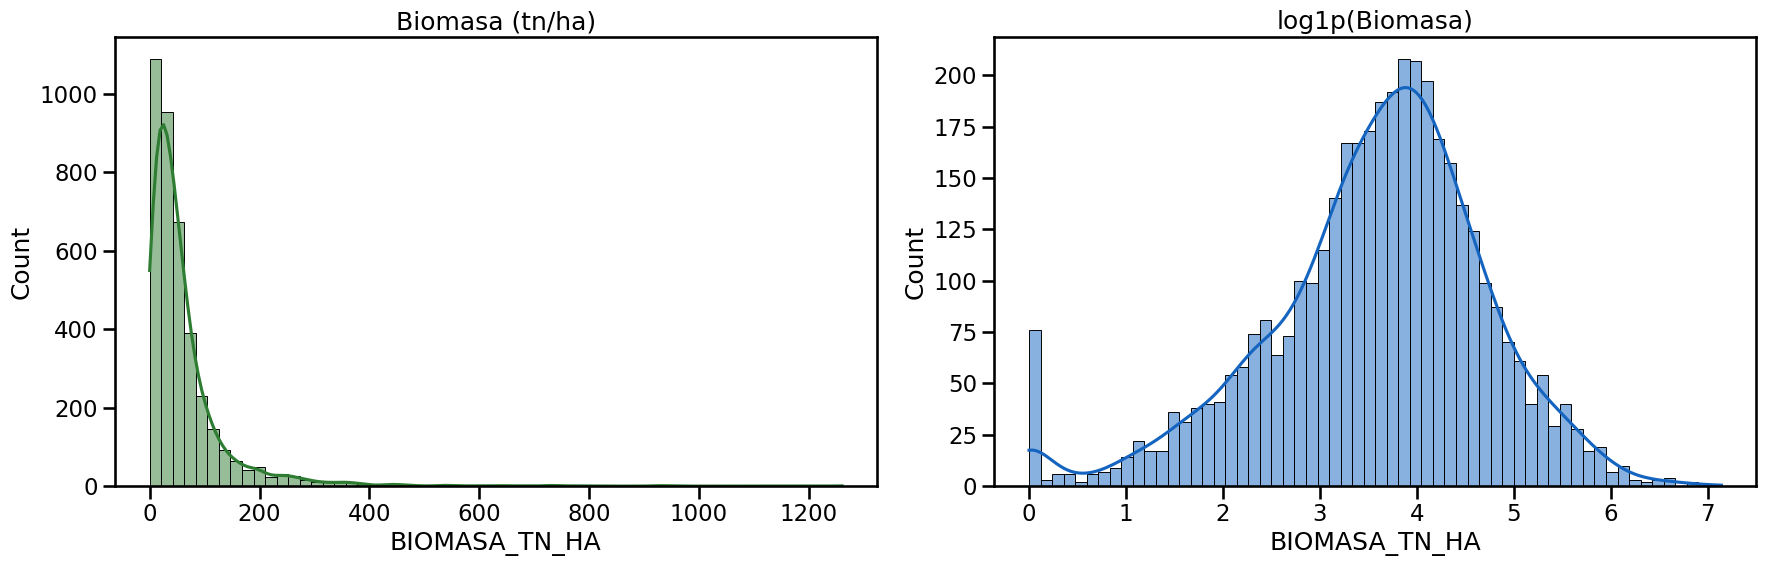

In [5]:
# Exploración previa al modelado
y = d[target]
print(f"Asimetría (skew) biomasa:        {stats.skew(y):.2f}")
print(f"Asimetría (skew) log1p(biomasa): {stats.skew(np.log1p(y)):.2f}")
print("Percentiles:", y.quantile([.5, .9, .95, .99]).round(1).to_dict())
print("UM con biomasa = 0:", (y == 0).sum())

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
sns.histplot(y, bins=60, kde=True, ax=ax[0], color="#2e7d32")
ax[0].set_title("Biomasa (tn/ha)")
sns.histplot(np.log1p(y), bins=60, kde=True, ax=ax[1], color="#1565c0")
ax[1].set_title("log1p(Biomasa)")
plt.tight_layout(); plt.show()

Se observa que la biomasa tiene una asimetría muy fuerte (skew = 4.55), la mediana es 39.7 tn/ha, pero el percentil 99 llega a 362 tn/ha y el máximo a 1.260. Con `log1p` la distribución se vuelve casi simétrica (skew = -0.67). Hay un pico en cero, lo que indica 75 UM con biomasa nula, que corresponden a las  UM sin individuos inventariables detectadas en el TP2. Esta asimetría justifica evaluar los modelos también en escala logarítmica y reportar MAE además de RMSE, porque el RMSE queda dominado por unas pocas UM de biomasa muy alta.

### 3.4.2. Biomasa por región

,n,media,mediana,desvio,maximo
REGION_OFC,,,,,
MON,103,9.7,5.4,11.4,84.6
ESP,262,34.0,26.5,29.4,150.8
DEL,18,40.7,32.0,25.4,81.8
PCH,2801,43.9,36.0,35.3,281.0
STB,298,111.2,90.8,93.0,642.2
SMI,166,128.7,119.3,94.1,727.5
BAP,242,197.4,166.1,181.8,1260.5


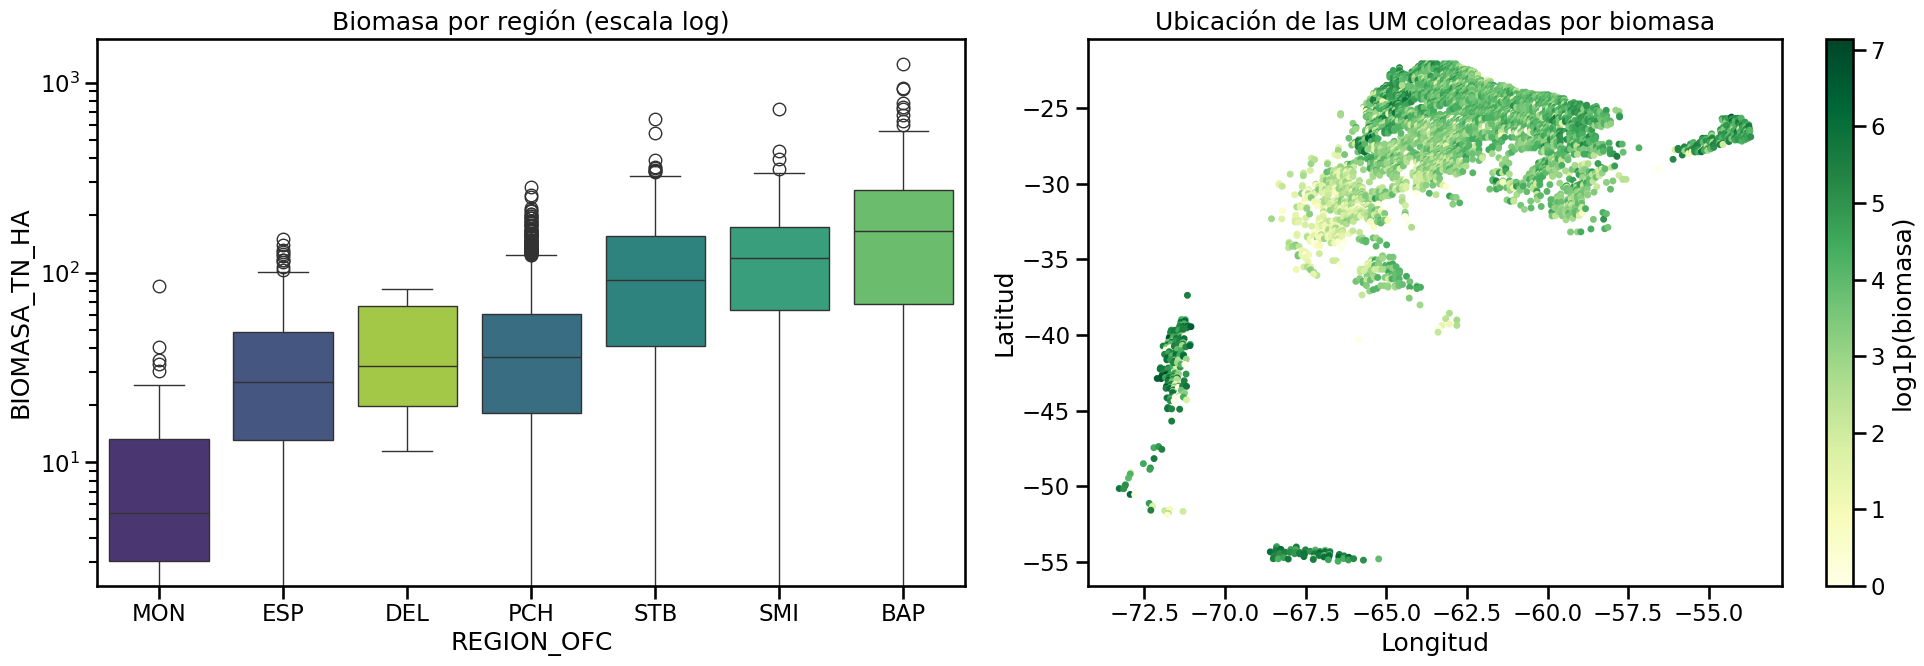

Kruskal-Wallis: KruskalResult(statistic=np.float64(758.1717992879621), pvalue=np.float64(1.674257082914195e-160))


In [6]:
resumen_reg = (d.groupby("REGION_OFC")[target]
                 .agg(n="count", media="mean", mediana="median", desvio="std", maximo="max")
                 .round(1).sort_values("mediana"))
display(resumen_reg)

orden = resumen_reg.index
fig, ax = plt.subplots(1, 2, figsize=(20, 7))
sns.boxplot(data=d, x="REGION_OFC", y=target, order=orden, hue="REGION_OFC",
            palette="viridis", legend=False, ax=ax[0])
ax[0].set_yscale("log"); ax[0].set_title("Biomasa por región (escala log)")
sc = ax[1].scatter(d.LONGITUD, d.LATITUD, c=np.log1p(d[target]), cmap="YlGn", s=12)
plt.colorbar(sc, ax=ax[1], label="log1p(biomasa)")
ax[1].set_title("Ubicación de las UM coloreadas por biomasa")
ax[1].set_xlabel("Longitud"); ax[1].set_ylabel("Latitud")
plt.tight_layout(); plt.show()

groups = [g[target].values for _, g in d.groupby("REGION_OFC")]
print("Kruskal-Wallis:", stats.kruskal(*groups))

La biomasa mediana va de 5.4 tn/ha en Monte (MON) a 166 tn/ha en Bosque Andino
Patagónico (BAP), una diferencia de más de 30 veces. Hay tres grupos: MON/ESPDEL/PCH (< 40 tn/ha), STB/SMI (90–120) y BAP (166). El BAP además tiene la mayor dispersión (máximo 1.260). El mapa confirma el patrón: los tonos oscuros se concentran en el noreste (Selva Misionera) y noroeste (Yungas) y en la Patagonia andina. El test de Kruskal-Wallis permite descartar que las diferencias sean azar.
Consecuencia para el modelado: la región será un predictor fuerte, y hay que evaluar si el modelo aprende algo más allá de "en qué región está la UM".

### 3.4.3. Correlación de los predictores con la biomasa

Correlación de Spearman (robusta a la asimetría) con log1p(biomasa), primero global y luego dentro de cada región. Esto permite ver si el efecto de la presión antrópica se mantiene una vez controlada la región.

/usr/local/lib/python3.13/dist-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/usr/local/lib/python3.13/dist-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


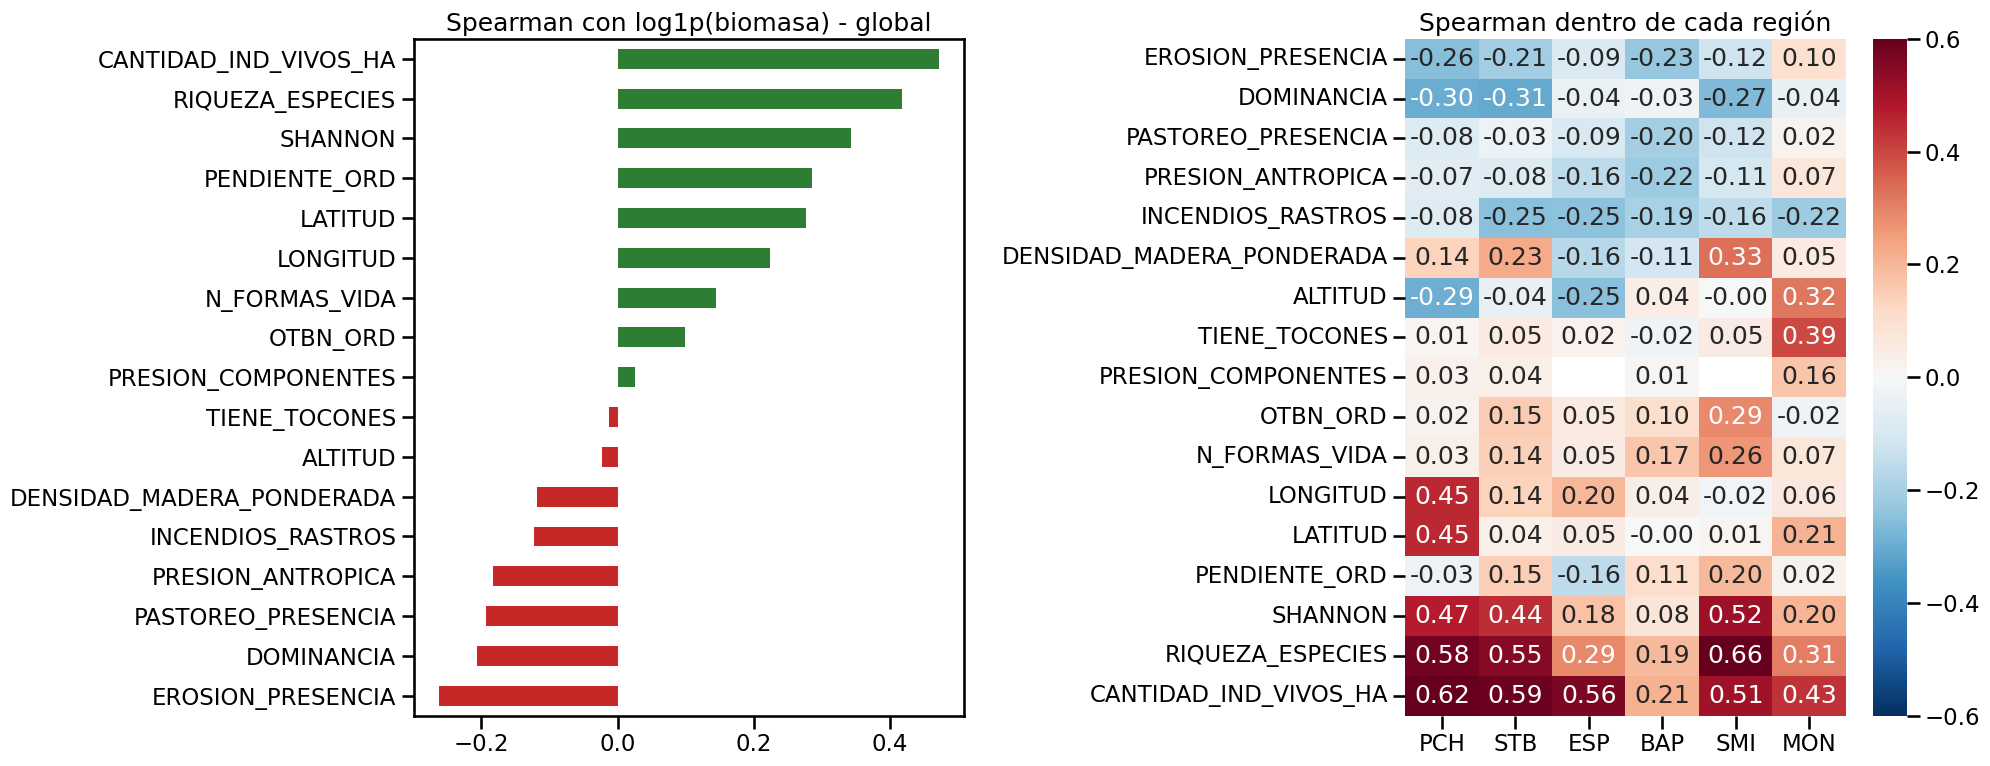

In [7]:
num_corr = num_features + ord_bin_features
y_log = np.log1p(d[target])

corr_glob = d[num_corr].corrwith(y_log, method="spearman").sort_values()

fig, ax = plt.subplots(1, 2, figsize=(20, 8))
corr_glob.plot.barh(ax=ax[0], color=["#c62828" if v < 0 else "#2e7d32" for v in corr_glob])
ax[0].set_title("Spearman con log1p(biomasa) - global")

# Dentro de cada región (solo regiones con n >= 100)
regs = [r for r, n in d["REGION_OFC"].value_counts().items() if n >= 100]
corr_reg = pd.DataFrame({r: d.loc[d.REGION_OFC == r, num_corr]
                              .corrwith(y_log[d.REGION_OFC == r], method="spearman")
                         for r in regs})
sns.heatmap(corr_reg.loc[corr_glob.index], annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-.6, vmax=.6, ax=ax[1])
ax[1].set_title("Spearman dentro de cada región")
plt.tight_layout(); plt.show()

### 3.4.4. Multicolinealidad


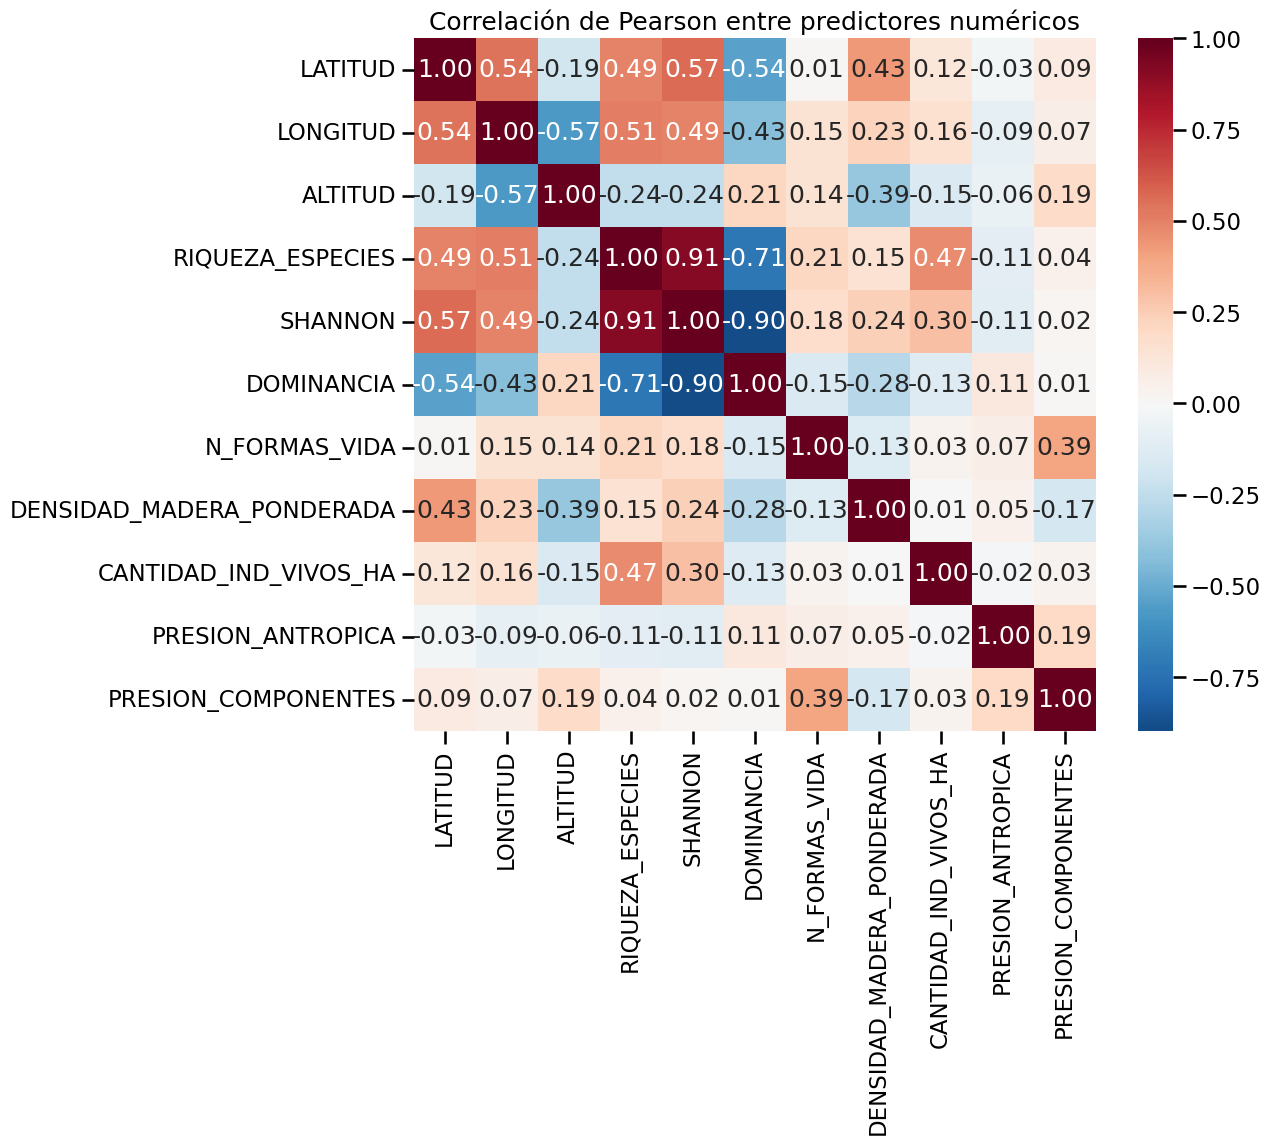

RIQUEZA_ESPECIES  SHANNON       0.91
SHANNON           DOMINANCIA    0.90
RIQUEZA_ESPECIES  DOMINANCIA    0.71
dtype: float64
SHANNON                      23.2
RIQUEZA_ESPECIES             11.1
DOMINANCIA                    7.8
LONGITUD                      2.7
LATITUD                       2.3
ALTITUD                       2.1
DENSIDAD_MADERA_PONDERADA     1.6
CANTIDAD_IND_VIVOS_HA         1.5
N_FORMAS_VIDA                 1.4
PRESION_COMPONENTES           1.3
PRESION_ANTROPICA             1.1
dtype: float64


In [8]:
Xn = d[num_features].copy()
Xn = Xn.fillna(Xn.median())

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(Xn.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlación de Pearson entre predictores numéricos")
plt.show()

# Pares muy correlacionados
c = Xn.corr().abs().where(np.triu(np.ones((len(num_features),)*2), 1).astype(bool)).stack()
print(c[c > 0.7].sort_values(ascending=False).round(2))

# VIF calculado a mano (sin statsmodels)
Z = (Xn - Xn.mean()) / Xn.std()
vif = {col: 1 / (1 - LinearRegression().fit(Z.drop(columns=col), Z[col])
                          .score(Z.drop(columns=col), Z[col]))
       for col in Z.columns}
print(pd.Series(vif).sort_values(ascending=False).round(1))

Hay tres pares con correlación alta: Riqueza–Shannon (0.91), Shannon–Dominancia (0.90) y Riqueza–Dominancia (0.71). El VIF confirma el problema en tres variables: Shannon (23.2), Riqueza (11.1) y Dominancia (7.8); el resto queda por debajo de 3. Esto no afecta a los modelos de árboles, pero sí la interpretación de los coeficientes del Ridge (ver 3.7.2). Mantenemos las tres variables y, para la dirección de sus efectos, nos apoyamos en las correlaciones simples y la dependencia parcial.

## 3.5. Modelos base y evaluación del desempeño

### 3.5.1. Modelos base

Comparamos cinco configuraciones, de menor a mayor flexibilidad:

- **Referencia ingenua:** predice siempre la mediana de biomasa del entrenamiento. Sirve como piso:  cualquier modelo útil debe superarlo.
- **Ridge (sin transformar el target):** regresión lineal regularizada, nuestro *baseline* lineal.
- **Ridge sobre log1p(biomasa):** dada la fuerte asimetría (3.4.1), probamos entrenar sobre el logaritmo.
- **Random Forest y Gradient Boosting (sobre log1p):** modelos de árboles, capaces de capturar relaciones no lineales e interacciones (por ejemplo, que el efecto de la altitud dependa de la región).

**Métricas:** R² (varianza explicada), RMSE (penaliza errores grandes), MAE (error típico en tn/ha) y R² en escala log1p. Se reportan en train y test: la diferencia entre ambos (`brecha_R2`) es el indicador de sobreajuste. Las predicciones se acotan en 0 porque la biomasa no puede ser negativa.

In [9]:
def evalua(nombre, modelo, usar_log=True):
    m = (TransformedTargetRegressor(regressor=modelo, func=np.log1p, inverse_func=np.expm1)
         if usar_log else modelo)
    m.fit(X_train, y_train)
    res = {"modelo": nombre}
    for split, Xs, ys in [("train", X_train, y_train), ("test", X_test, y_test)]:
        p = np.clip(m.predict(Xs), 0, None)
        res[f"R2_{split}"] = r2_score(ys, p)
        res[f"RMSE_{split}"] = np.sqrt(mean_squared_error(ys, p))
        res[f"MAE_{split}"] = mean_absolute_error(ys, p)
        res[f"R2log_{split}"] = r2_score(np.log1p(ys), np.log1p(p))
    res["brecha_R2"] = res["R2_train"] - res["R2_test"]
    return res, m

configs = [
    ("Referencia (mediana)", DummyRegressor(strategy="median"), False),
    ("Ridge (sin log)", Pipeline([("pre", preprocesador), ("m", Ridge(alpha=1.0))]), False),
    ("Ridge (log1p)", Pipeline([("pre", preprocesador), ("m", Ridge(alpha=1.0))]), True),
    ("Random Forest (log1p)", Pipeline([("pre", preprocesador),
        ("m", RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))]), True),
    ("Gradient Boosting (log1p)", Pipeline([("pre", preprocesador),
        ("m", GradientBoostingRegressor(random_state=42))]), True),
]
resultados, modelos = [], {}
for n, mod, lg in configs:
    r, m = evalua(n, mod, lg)
    resultados.append(r); modelos[n] = m

tabla = pd.DataFrame(resultados).set_index("modelo").round(3)
tabla.T

modelo,Referencia (mediana),Ridge (sin log),Ridge (log1p),Random Forest (log1p),Gradient Boosting (log1p)
R2_train,-0.072,0.443,0.296,0.879,0.613
RMSE_train,79.478,57.275,64.396,26.716,47.753
MAE_train,41.762,30.736,31.318,10.587,23.020
R2log_train,-0.016,0.429,0.602,0.964,0.793
R2_test,-0.073,0.443,0.361,0.544,0.557
RMSE_test,80.556,58.067,62.192,52.495,51.790
MAE_test,42.942,31.299,30.725,26.286,26.292
R2log_test,-0.019,0.453,0.601,0.736,0.730
brecha_R2,0.000,0.001,-0.065,0.334,0.056


### 3.5.2. Gráficos real vs. predicho

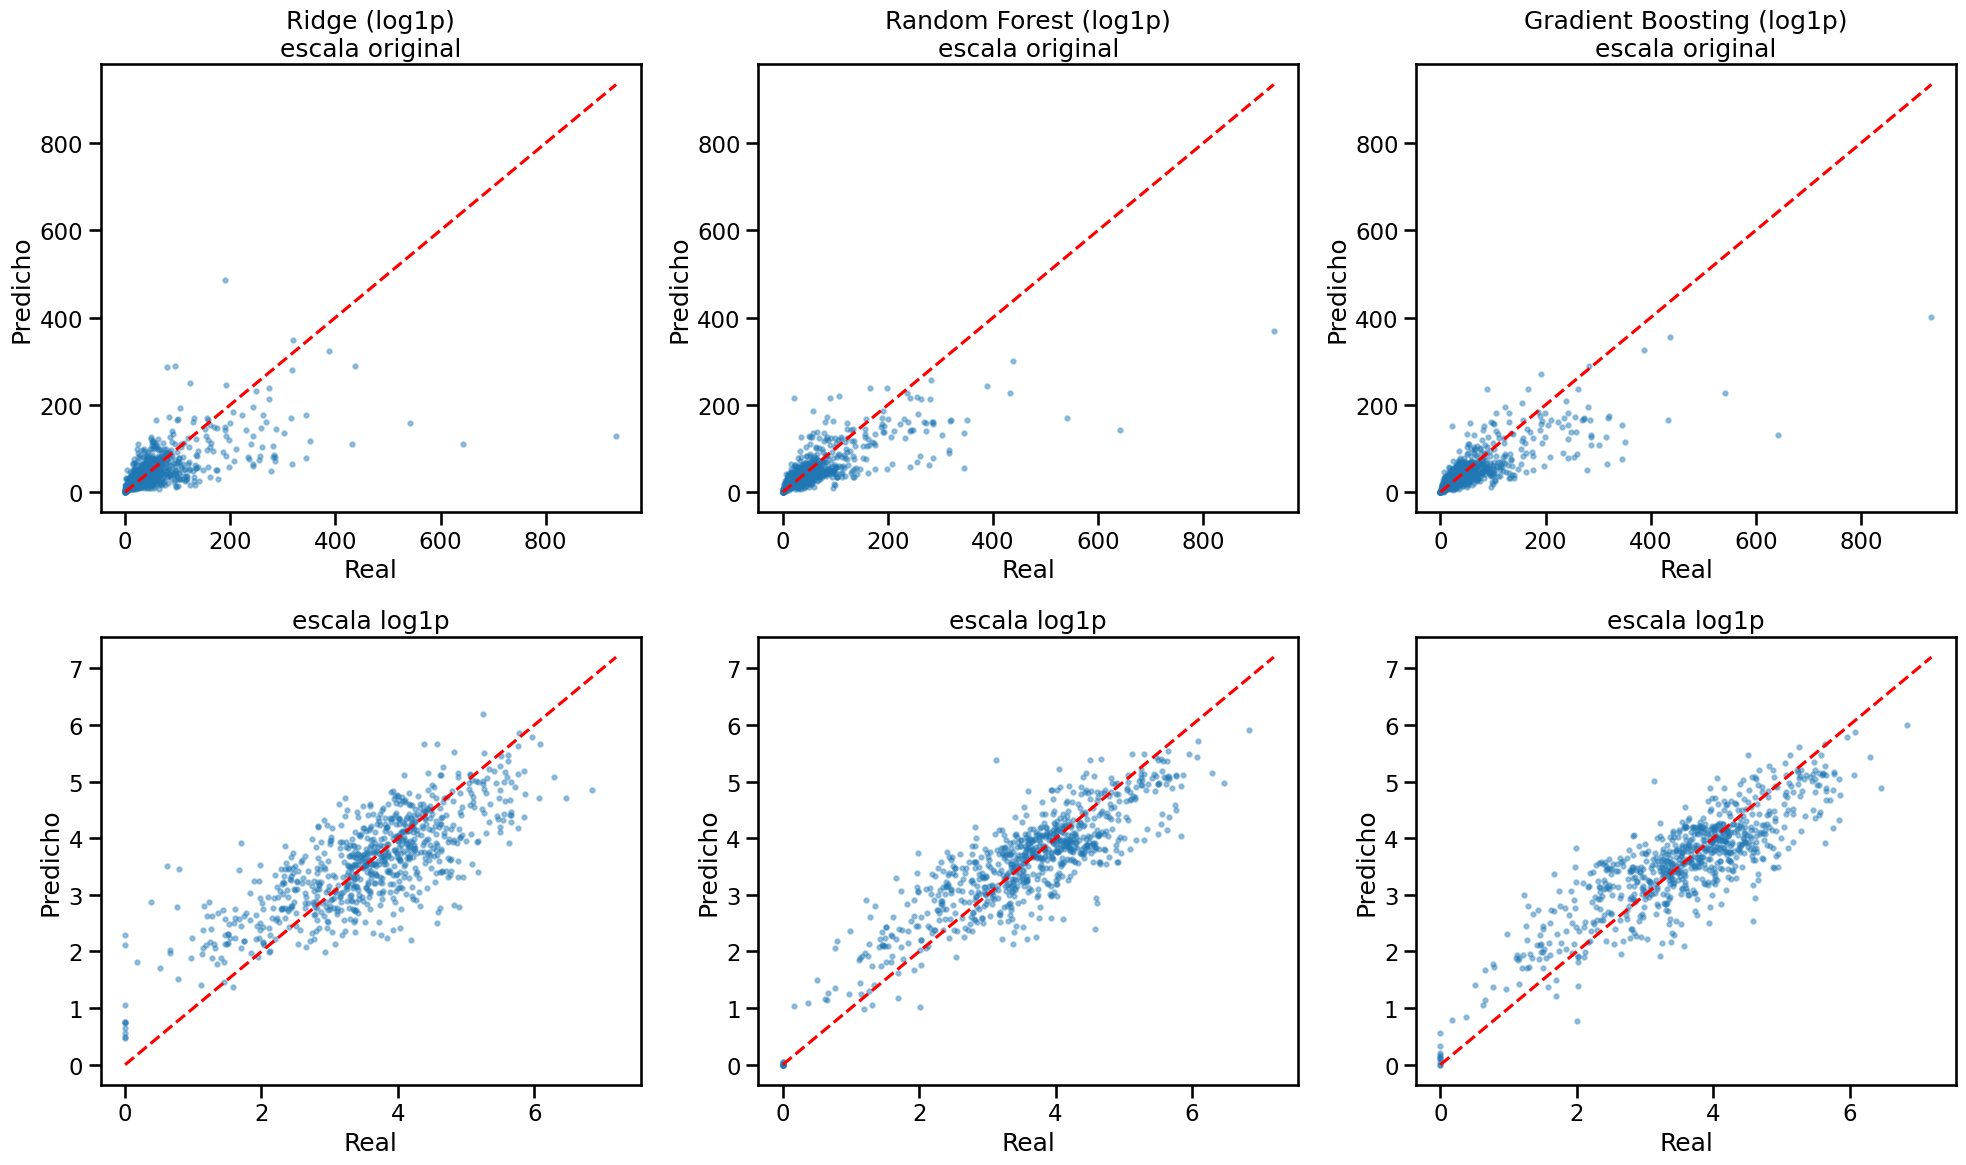

In [10]:
nombres = ["Ridge (log1p)", "Random Forest (log1p)", "Gradient Boosting (log1p)"]
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for j, n in enumerate(nombres):
    p = np.clip(modelos[n].predict(X_test), 0, None)
    ax = axes[0, j]
    ax.scatter(y_test, p, s=10, alpha=.4)
    lim = max(y_test.max(), p.max())
    ax.plot([0, lim], [0, lim], "r--")
    ax.set_title(f"{n}\nescala original"); ax.set_xlabel("Real"); ax.set_ylabel("Predicho")
    ax = axes[1, j]
    ax.scatter(np.log1p(y_test), np.log1p(p), s=10, alpha=.4)
    ax.plot([0, 7.2], [0, 7.2], "r--")
    ax.set_title("escala log1p"); ax.set_xlabel("Real"); ax.set_ylabel("Predicho")
plt.tight_layout(); plt.show()

Se observa que en escala original, el ajuste es moderado para los tres modelos. La mayoría de las UM tiene biomasas bajas (< 100 tn/ha), donde los puntos se concentran cerca de la diagonal pero con una dispersión considerable, coherente con los R² de test de 0.36–0.56 y el MAE de 26–31 tn/ha de 3.5.1 (frente a una mediana de biomasa de 39.7 tn/ha).

La escala log1p permite ver mejor la estructura, la nube sigue la diagonal con forma de abanico y una leve regresión hacia la media (se sobreestiman un poco las UM de biomasa baja y se subestiman las de biomasa alta). Los modelos de árboles (RF y GB) tienen una nube más compacta que Ridge, y ambos predicen prácticamente en cero las UM sin biomasa (puntos en el origen), mientras que Ridge no logra reproducir esos ceros (predice entre 0.5 y 2.3 en escala log). Esto último se analiza en 3.5.4.

### 3.5.4. La UM con biomasa cero inflan las métricas

In [11]:
print("UM sin biomasa (total):", (d[target] == 0).sum())
print(d.loc[d[target] == 0, ["CANTIDAD_IND_VIVOS_HA", "RIQUEZA_ESPECIES"]].describe().loc[["count", "max"]])

# Métricas en test excluyendo esas UM
mask = (y_test > 0).values
filas = []
for n in nombres:
    p = np.clip(modelos[n].predict(X_test), 0, None)
    filas.append({"modelo": n,
                  "R2": r2_score(y_test[mask], p[mask]),
                  "R2_log": r2_score(np.log1p(y_test[mask]), np.log1p(p[mask])),
                  "MAE": mean_absolute_error(y_test[mask], p[mask]),
                  "RMSE": np.sqrt(mean_squared_error(y_test[mask], p[mask]))})
pd.DataFrame(filas).set_index("modelo").round(3)

UM sin biomasa (total): 75
       CANTIDAD_IND_VIVOS_HA  RIQUEZA_ESPECIES
count                   75.0              75.0
max                      0.0               0.0


,R2,R2_log,MAE,RMSE
modelo,,,,
Ridge (log1p),0.356,0.560,31.093,62.594
Random Forest (log1p),0.541,0.699,26.628,52.836
Gradient Boosting (log1p),0.553,0.692,26.632,52.126


Las 75 UM con biomasa 0 del conjunto de modelado (76 en el dataset; la restante no tiene región y se excluyó en 3.3) tienen además `CANTIDAD_IND_VIVOS_HA = 0` y `RIQUEZA_ESPECIES = 0`. Es decir, son UM sin individuos inventariables, donde la biomasa nula es consecuencia directa de que no hay árboles, y los modelos de árboles las predicen casi perfectamente.

Resultados obtenidos hasta aquí:

- **Todos los modelos superan a la referencia** (R² ≈ -0.07 al predecir siempre la mediana). Las variables ambientales, de composición y de presión antrópica contienen señal real sobre la biomasa.
- **El Ridge no sobreajusta pero tiene capacidad limitada:** R² idéntico en train y test (0.44). La relación entre predictores y biomasa no es lineal.
- **Random Forest sobreajusta:** R² de 0.88 en train contra 0.55 en test (brecha de 0.33), con un error en train (MAE 10.6 tn/ha) menos de la mitad que en test (26.2). Gradient Boosting tiene una brecha de solo 0.06 y desempeño en test equivalente, por lo que es más confiable como modelo candidato. Esto responde directamente la pregunta de sobreajuste de la consigna, y en 3.6 intentamos reducirlo.
- **El logaritmo cambia qué se optimiza:** en el Ridge, entrenar en log mejora el ajuste en la mayoría de UM (R² log de 0.45 a 0.60) pero empeora el R² en escala original (0.44 a 0.36), porque se pierde precisión en las pocas UM de biomasa muy alta.
 **Los modelos subestiman sistemáticamente las UM de alta biomasa:** en los gráficos, los puntos de real > 200 tn/ha quedan casi todos bajo la diagonal. El sesgo por región se cuantifica con el modelo final en 3.8.1: es negativo en todas las regiones y se concentra en BAP, STB y SMI. Con estos predictores el modelo captura mejor el bosque chaqueño que los bosques húmedos de gran porte. Es coherente con el TP1: ahí la biomasa depende de pocos individuos muy grandes, algo que las variables ambientales no capturan y las alométricas sí (lo retomamos en 3.10).

## 3.6. Sobreajuste, validación cruzada, regularización y ajuste de hiperparámetros

### 3.6.1. Validación cruzada estratificada

Un único split train/test da una sola estimación del desempeño, que depende de qué UM cayeron en cada conjunto. Para medir su estabilidad usamos validación cruzada de 5 folds sobre el conjunto de entrenamiento, estratificada por región. El desvío entre folds indica cuánto varía el desempeño según la muestra. El conjunto de test queda intacto para la evaluación final.

In [12]:
def r2_log(yt, yp):
    return r2_score(np.log1p(yt), np.log1p(np.clip(yp, 0, None)))

scoring = {"R2": "r2", "R2_log": make_scorer(r2_log), "MAE": "neg_mean_absolute_error"}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
strat_train = d.loc[X_train.index, "REGION_OFC"]

def con_log(reg):
    return TransformedTargetRegressor(
        regressor=Pipeline([("pre", preprocesador), ("m", reg)]),
        func=np.log1p, inverse_func=np.expm1)

modelos_cv = {
    "Ridge (log1p)": con_log(Ridge(alpha=1.0)),
    "Random Forest": con_log(RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)),
    "Gradient Boosting": con_log(GradientBoostingRegressor(random_state=42)),
}

filas = []
for n, m in modelos_cv.items():
    cv = cross_validate(m, X_train, y_train, cv=skf.split(X_train, strat_train),
                        scoring=scoring, return_train_score=True)
    filas.append({"modelo": n,
                  "R2_train": cv["train_R2"].mean(),
                  "R2_val": cv["test_R2"].mean(), "R2_val_sd": cv["test_R2"].std(),
                  "R2_log_val": cv["test_R2_log"].mean(),
                  "MAE_val": -cv["test_MAE"].mean(), "MAE_sd": cv["test_MAE"].std()})
pd.DataFrame(filas).set_index("modelo").round(3)

,R2_train,R2_val,R2_val_sd,R2_log_val,MAE_val,MAE_sd
modelo,,,,,,
Ridge (log1p),0.302,0.245,0.077,0.584,32.299,1.777
Random Forest,0.868,0.485,0.055,0.733,25.942,1.244
Gradient Boosting,0.620,0.451,0.055,0.722,26.661,1.035


### 3.6.2. Regularización del Random Forest


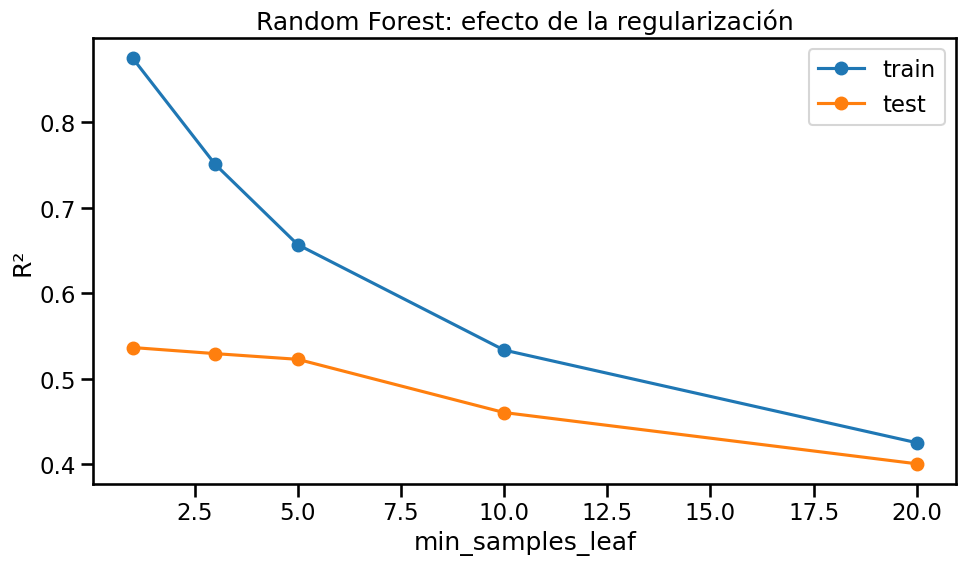

,min_samples_leaf,max_depth,R2_train,R2_test,brecha
0,1,None,0.875,0.536,0.339
1,1,12,0.820,0.532,0.287
2,1,8,0.652,0.506,0.146
3,3,None,0.751,0.529,0.221
4,3,12,0.727,0.529,0.198
5,3,8,0.620,0.498,0.122
6,5,None,0.657,0.523,0.134
7,5,12,0.645,0.512,0.133
8,5,8,0.578,0.492,0.086
9,10,None,0.533,0.460,0.073


In [13]:
filas = []
for msl in [1, 3, 5, 10, 20]:
    for md in [None, 12, 8]:
        rf = con_log(RandomForestRegressor(n_estimators=200, min_samples_leaf=msl, max_depth=md,
                                           max_features=0.5, random_state=42, n_jobs=-1))
        rf.fit(X_train, y_train)
        filas.append({"min_samples_leaf": msl, "max_depth": str(md),
                      "R2_train": r2_score(y_train, rf.predict(X_train)),
                      "R2_test": r2_score(y_test, rf.predict(X_test))})
reg = pd.DataFrame(filas)
reg["brecha"] = reg["R2_train"] - reg["R2_test"]

fig, ax = plt.subplots(figsize=(10, 6))
sub = reg[reg["max_depth"] == "None"]
ax.plot(sub["min_samples_leaf"], sub["R2_train"], "o-", label="train")
ax.plot(sub["min_samples_leaf"], sub["R2_test"], "o-", label="test")
ax.set_xlabel("min_samples_leaf"); ax.set_ylabel("R²")
ax.set_title("Random Forest: efecto de la regularización"); ax.legend()
plt.tight_layout(); plt.show()
reg.round(3)

### 3.6.3 Ajuste de hiperparámetros
Usamos `RandomizedSearchCV` sobre el conjunto de entrenamiento (CV de 3 folds estratificados,
optimizando R²). El test se reserva para la evaluación final. En 3.6.2 se observó el R² de test solo para ilustrar el trade-off de la regularización, y la elección del Gradient Boosting ajustado se contrastó con el test; por eso la selección del modelo debe leerse junto con la validación cruzada (R² CV de 3 folds del GB ajustado: 0.536). Es una limitación metodológica menor, ya que las diferencias entre modelos candidatos son moderadas.

In [14]:
cv3 = list(StratifiedKFold(n_splits=3, shuffle=True, random_state=42).split(X_train, strat_train))

gb_space = {"regressor__m__n_estimators": [100, 200, 300],
            "regressor__m__learning_rate": [0.01, 0.03, 0.05, 0.1],
            "regressor__m__max_depth": [2, 3, 4, 5],
            "regressor__m__min_samples_leaf": [5, 10, 20, 40],
            "regressor__m__subsample": [0.6, 0.8, 1.0]}
gs = RandomizedSearchCV(modelos_cv["Gradient Boosting"], gb_space, n_iter=8, cv=cv3,
                        scoring="r2", random_state=42, n_jobs=1)
gs.fit(X_train, y_train)
gb_ajustado = gs.best_estimator_
print(gs.best_params_, round(gs.best_score_, 3))

rf_space = {"regressor__m__n_estimators": [200, 300],
            "regressor__m__max_depth": [None, 10, 15, 20],
            "regressor__m__min_samples_leaf": [1, 2, 3, 5, 8],
            "regressor__m__max_features": [0.3, 0.5, 0.7, 1.0]}
rs = RandomizedSearchCV(modelos_cv["Random Forest"], rf_space, n_iter=6, cv=cv3,
                        scoring="r2", random_state=42, n_jobs=1)
rs.fit(X_train, y_train)
rf_ajustado = rs.best_estimator_

for n, m in [("Gradient Boosting ajustado", gb_ajustado), ("Random Forest ajustado", rf_ajustado)]:
    print(n, "| R² train:", round(r2_score(y_train, m.predict(X_train)), 3),
          "| R² test:", round(r2_score(y_test, m.predict(X_test)), 3),
          "| R² log test:", round(r2_log(y_test, m.predict(X_test)), 3),
          "| MAE test:", round(mean_absolute_error(y_test, m.predict(X_test)), 2))

{'regressor__m__subsample': 0.6, 'regressor__m__n_estimators': 300, 'regressor__m__min_samples_leaf': 5, 'regressor__m__max_depth': 5, 'regressor__m__learning_rate': 0.05} 0.536
Gradient Boosting ajustado | R² train: 0.846 | R² test: 0.63 | R² log test: 0.756 | MAE test: 24.63
Random Forest ajustado | R² train: 0.883 | R² test: 0.548 | R² log test: 0.738 | MAE test: 26.21


### 3.6.4. Curva de aprendizaje

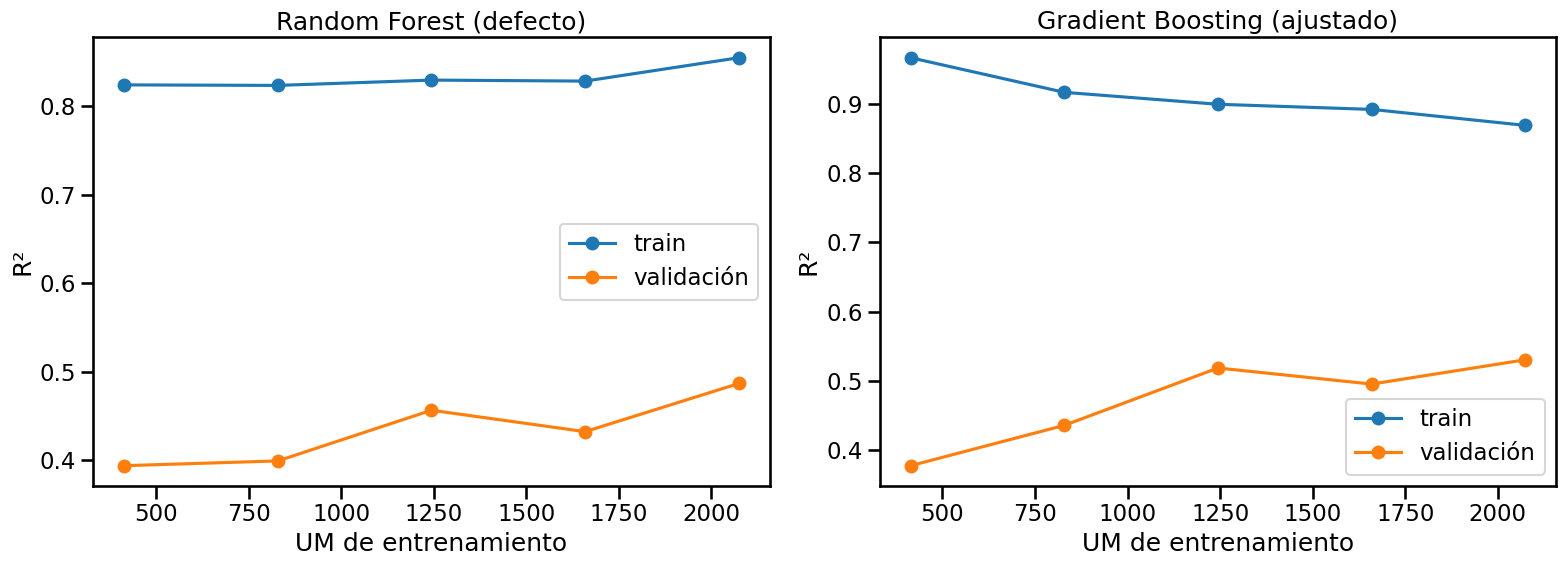

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
for a, (n, m) in zip(ax, [("Random Forest (defecto)", modelos_cv["Random Forest"]),
                          ("Gradient Boosting (ajustado)", gb_ajustado)]):
    ts, tr, va = learning_curve(m, X_train, y_train, cv=cv3,
                                train_sizes=[.2, .4, .6, .8, 1.0], scoring="r2", n_jobs=1)
    a.plot(ts, tr.mean(1), "o-", label="train")
    a.plot(ts, va.mean(1), "o-", label="validación")
    a.set_title(n); a.set_xlabel("UM de entrenamiento"); a.set_ylabel("R²"); a.legend()
plt.tight_layout(); plt.show()

Resultados obtenidos hasta aquí:

- **La estimación única de test era optimista.** Con validación cruzada, el R² del Random Forest es 0.485 ± 0.055 (folds entre 0.44 y 0.59), por debajo del 0.55 del split inicial. Ningún valor de R² debe leerse como exacto: el desempeño esperado ronda 0.45 a 0.55 según la muestra.
- **Sobreajuste y regularización son un trade-off.** Al aumentar `min_samples_leaf` de 1 a 20 la brecha train-test del Random Forest baja de 0.34 a 0.03, pero el R² de test cae de 0.54 a 0.40. Un modelo sin sobreajuste no es necesariamente mejor: aquí "aprende menos" en vez de "generalizar mejor".
- **El Gradient Boosting ajustado es el mejor modelo** (R² test 0.63, R² log 0.756, MAE 24.6 tn/ha) y supera al Random Forest incluso ajustado. Tiene una brecha de 0.22, pero el criterio para elegirlo es el desempeño en datos no vistos, que es el mejor.
- **Más datos ayudarían.** La curva de validación sigue subiendo al aumentar el entrenamiento y no se estabiliza. Con la información disponible, el modelo tiene aún margen de mejora si se agregaran UM (sobre todo de las regiones con poca representación).
- **Limitación:** la búsqueda de hiperparámetros fue acotada (pocas combinaciones); los valores óptimos son una aproximación.

### 3.6.5. Granularidad geográfica


In [16]:
def make_pre(num, ordb, cat, indicador=False):
    return ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", RobustScaler())]), num),
        ("ord_bin", Pipeline([("imputer", SimpleImputer(strategy="most_frequent",
                                                        add_indicator=indicador))]), ordb),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat),
    ])

mejores_params = {k.split("__")[-1]: v for k, v in gs.best_params_.items()}

def make_gb(num, ordb, cat, indicador=False):
    return TransformedTargetRegressor(
        regressor=Pipeline([("pre", make_pre(num, ordb, cat, indicador)),
                            ("m", GradientBoostingRegressor(random_state=42, **mejores_params))]),
        func=np.log1p, inverse_func=np.expm1)

variantes = {
    "Base":                    make_gb(num_features, ord_bin_features, cat_features),
    "+ flags de nulos":        make_gb(num_features, ord_bin_features, cat_features, indicador=True),
    "+ SUBREG y PROVINCIA":    make_gb(num_features, ord_bin_features,
                                       cat_features + ["SUBREG", "PROVINCIA_NOMBRE"]),
}
cv5 = list(StratifiedKFold(5, shuffle=True, random_state=42).split(X_train, strat_train))
Xtr_all = d.loc[X_train.index, predictores + ["SUBREG", "PROVINCIA_NOMBRE"]]

filas = []
for n, m in variantes.items():
    cv = cross_validate(m, Xtr_all, y_train, cv=cv5, scoring=scoring)
    filas.append({"variante": n, "R2_val": cv["test_R2"].mean(), "sd": cv["test_R2"].std(),
                  "R2_log_val": cv["test_R2_log"].mean(), "MAE_val": -cv["test_MAE"].mean()})
pd.DataFrame(filas).set_index("variante").round(3)

,R2_val,sd,R2_log_val,MAE_val
variante,,,,
Base,0.519,0.089,0.740,25.499
+ flags de nulos,0.529,0.075,0.741,25.475
+ SUBREG y PROVINCIA,0.539,0.057,0.745,25.238


Agregar flags de nulos (R² CV 0.529 vs 0.519 de la base) o `SUBREG` y `PROVINCIA_NOMBRE` (0.539, con menor desvío) produce mejoras pequeñas, del orden del desvío entre folds (0.06–0.09). Las subdivisiones aportan algo de información geográfica fina dentro de la región, por lo que matizamos lo dicho en 3.2: no son totalmente redundantes, pero la ganancia es marginal. Conservamos el modelo base por parsimonia y para no aumentar la dimensionalidad.

## 3.7. Importancia de variables


### 3.7.1. Importancia por permutación

Para responder la pregunta central de la consigna usamos modelo elegido (Gradient Boosting ajustado, sección 3.6), calculada en el conjunto de test: mide  cuánto empeora el R² del modelo al mezclar aleatoriamente los valores de una variable, manteniendo el resto intactas. A diferencia de la importancia nativa de los árboles (`feature_importances_`), esta  mide el aporte real a la predicción fuera de muestra, y no favorece artificialmente a variables con  muchas categorías o muchos valores distintos.

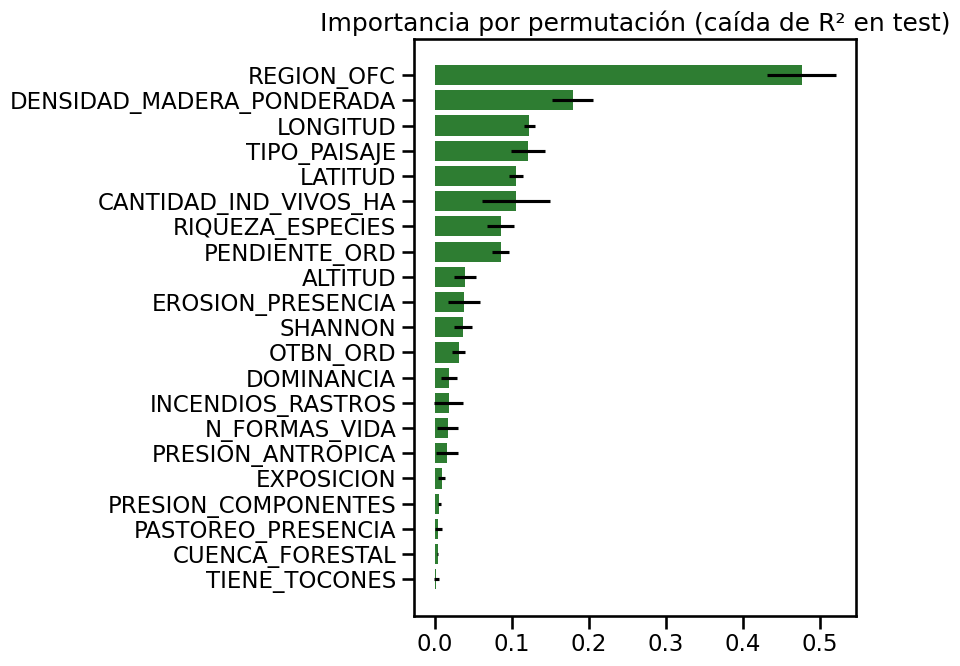

In [17]:

modelo_final = gb_ajustado
perm = permutation_importance(modelo_final, X_test, y_test,
                              n_repeats=20, random_state=42, scoring="r2")
imp = (pd.DataFrame({"variable": X_test.columns,
                     "importancia": perm.importances_mean,
                     "sd": perm.importances_std})
         .sort_values("importancia", ascending=False))

fig, ax = plt.subplots(figsize=(9, 7))
plot_data = imp[imp.importancia > 0.001].sort_values("importancia")
ax.barh(plot_data.variable, plot_data.importancia, xerr=plot_data.sd, color="#2e7d32")
ax.set_title("Importancia por permutación (caída de R² en test)")
plt.tight_layout(); plt.show()

Resultados obtenidos hasta aquí:

- **`REGION_OFC` domina de forma clara** (caída de R² de 0.47, muy por encima de la segunda variable). Confirma cuantitativamente lo que se veía en 3.4.2: la región de pertenencia resume gran parte de la variación de biomasa (tipo de bosque, clima, historia de uso).
- **Después de la región, importan `DENSIDAD_MADERA_PONDERADA` (0.17), `LONGITUD` (0.12), `TIPO_PAISAJE` (0.12), `CANTIDAD_IND_VIVOS_HA` (0.11) y `LATITUD` (0.10).** Es decir: qué especies componen el rodal (vía su densidad de madera), la posición geográfica dentro de la región, el paisaje y cuántos árboles hay por hectárea.
- **`PENDIENTE_ORD` (0.09) y `RIQUEZA_ESPECIES` (0.08)** también aportan.
- **La presión antrópica pesa poco en importancia predictiva** (`PRESION_ANTROPICA` 0.014, `PASTOREO_PRESENCIA` casi 0, `INCENDIOS_RASTROS` 0.017), aun cuando en 3.4.3 mostraban correlación con la biomasa. Esto sugiere que su efecto está mayormente capturado por la región (las regiones con más presión antrópica también tienden a tener menos biomasa por razones estructurales), y que no aporta información adicional una vez que el modelo ya conoce la región.

### 3.7.2. Coeficiente del modelo lineal


La importancia por permutación dice *cuánto* aporta una variable, pero no en qué dirección. Para eso
miramos los coeficientes del Ridge (predictores estandarizados, target en log1p): un coeficiente
positivo indica que a mayor valor de la variable, mayor biomasa esperada.

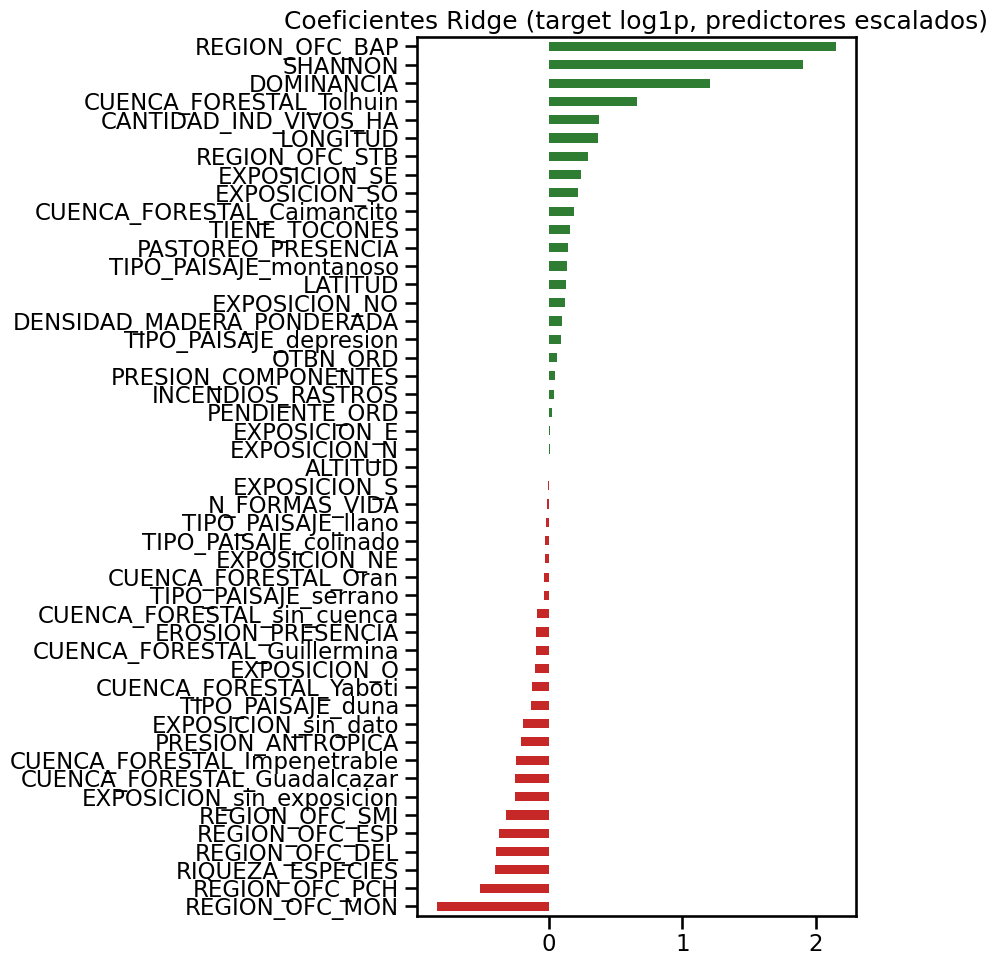

In [18]:
ridge_full = con_log(Ridge(alpha=1.0))
ridge_full.fit(X_train, y_train)

ohe = ridge_full.regressor_.named_steps["pre"].named_transformers_["cat"].named_steps["onehot"]
nombres_cat = ohe.get_feature_names_out(cat_features)
nombres_coef = num_features + ord_bin_features + list(nombres_cat)
coefs = pd.Series(ridge_full.regressor_.named_steps["m"].coef_, index=nombres_coef).sort_values()

fig, ax = plt.subplots(figsize=(9, 10))
coefs.plot.barh(ax=ax, color=["#c62828" if v < 0 else "#2e7d32" for v in coefs])
ax.set_title("Coeficientes Ridge (target log1p, predictores escalados)")
plt.tight_layout(); plt.show()

Resultados obtenidos hasta aquí: el signo de las categorías de `REGION_OFC` confirma la jerarquía de 3.4.2: BAP (+2.15) y STB (+0.29) con coeficiente positivo (más biomasa que el promedio), MON (-0.84) y PCH (-0.52) con
coeficiente negativo. `CANTIDAD_IND_VIVOS_HA` (+0.38) y `LONGITUD` (+0.37, coherente con más biomasa hacia el este/las Yungas y Selva Misionera) tienen efecto positivo, igual que `PASTOREO_PRESENCIA` (+0.15) — resultado contraintuitivo que retomamos abajo. `PRESION_ANTROPICA` (-0.21) y
`EROSION_PRESENCIA` (-0.09) sí tienen el signo esperado.

**`SHANNON` (+1.91) y `DOMINANCIA` (+1.21):** ambas aparecen con coeficiente muy alto y del mismo signo, pese a que en 3.4.3 la correlación de Shannon con biomasa era positiva y la de dominancia negativa. Esto es un síntoma clásico de la multicolinealidad detectada en 3.4.4 (correlación de -0.90 entre ambas): cuando dos predictores están muy correlacionados, el modelo lineal puede repartir su efecto de forma inestable, incluso invirtiendo el signo aparente. Por esta razón, para la dirección de este tipo de variables confiamos más en las correlaciones simples de 3.4.3 y en las curvas de dependencia parcial (a continuación) que en el coeficiente del Ridge.

### 3.7.3. Dependencia parcial de las variables principales

Las curvas de dependencia parcial muestran la predicción promedio del modelo al variar una variable,
manteniendo el resto en sus valores observados. A diferencia del coeficiente lineal, permiten ver
relaciones no lineales o con umbrales.

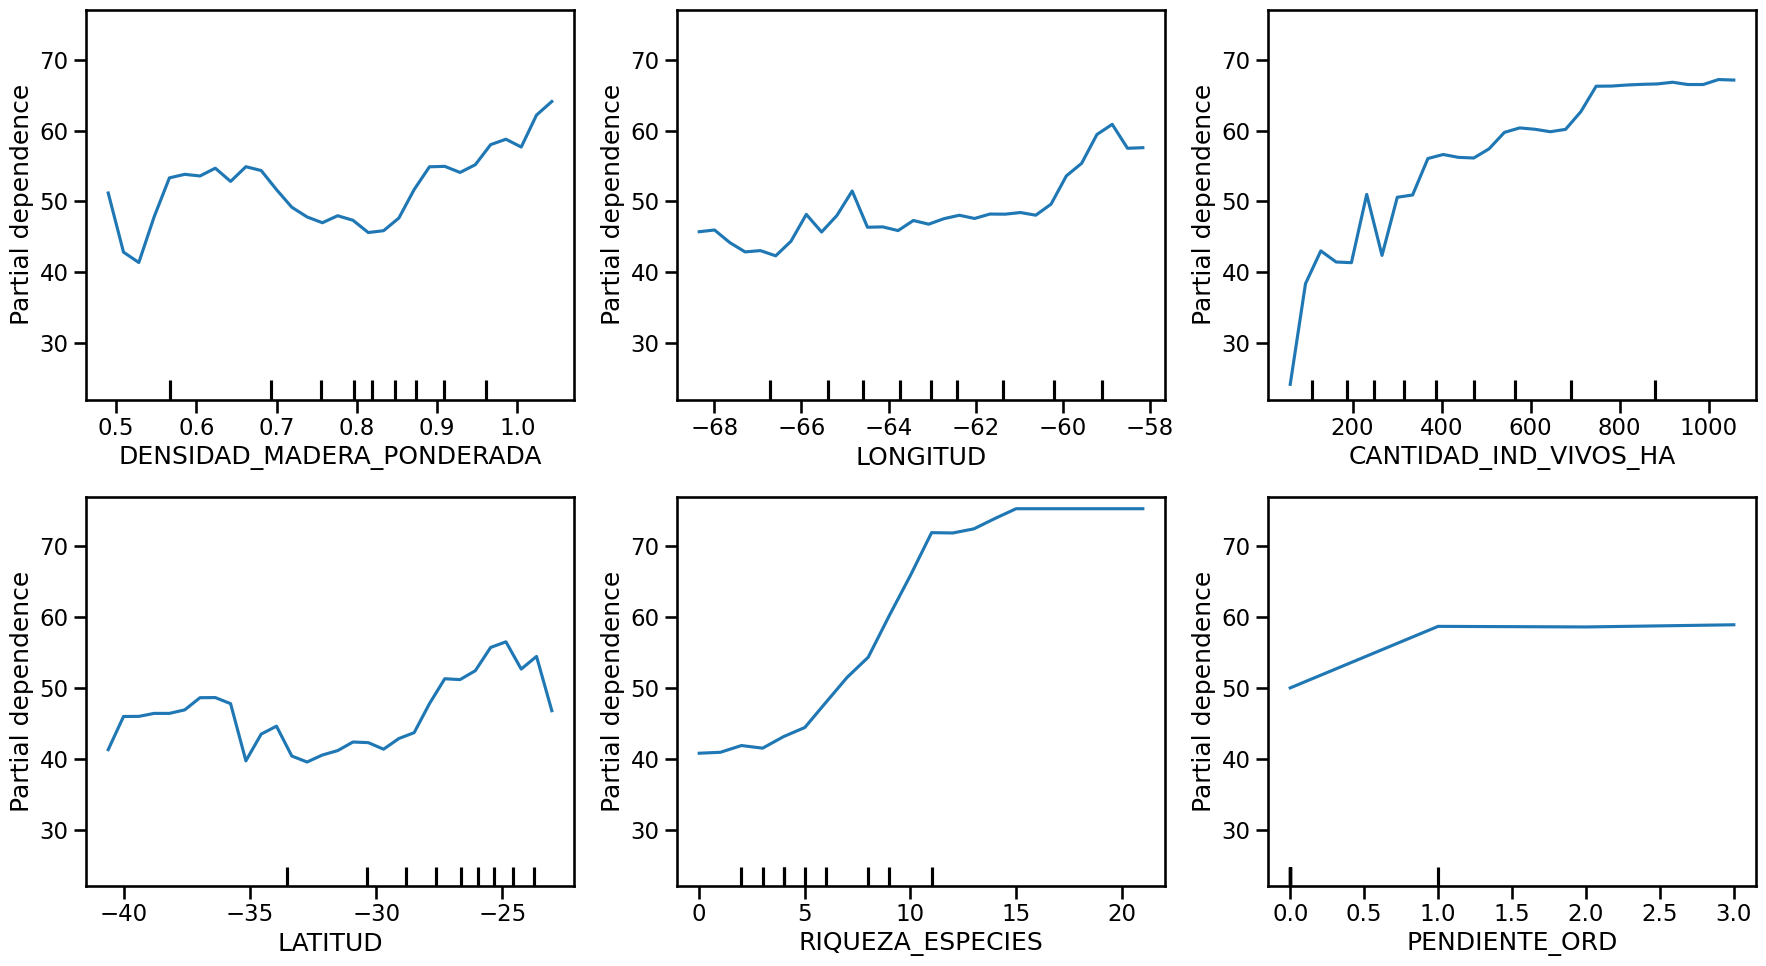

In [19]:

top_num = ["DENSIDAD_MADERA_PONDERADA", "LONGITUD", "CANTIDAD_IND_VIVOS_HA",
           "LATITUD", "RIQUEZA_ESPECIES", "PENDIENTE_ORD"]
fig, ax = plt.subplots(2, 3, figsize=(18, 10))
PartialDependenceDisplay.from_estimator(modelo_final, X_train, top_num, ax=ax.ravel(), grid_resolution=30)
plt.tight_layout(); plt.show()

**Hallazgos:**

- **`RIQUEZA_ESPECIES` muestra un umbral claro:** la biomasa esperada sube fuerte entre 5 y 15 especies
  (de ~45 a ~75 tn/ha) y luego se aplana. Rodales muy pobres en especies casi no varían su biomasa
  esperada al sumar una especie más, pero pasar de "pobre" a "moderadamente diverso" sí importa mucho.
- **`CANTIDAD_IND_VIVOS_HA` tiene un efecto fuerte y de rendimientos decrecientes:** sube muy rápido
  hasta ~400 individuos/ha y luego se estabiliza cerca de 65–68 tn/ha. Tiene sentido: más árboles por
  hectárea generalmente implica más biomasa, pero solo hasta cierta densidad (después, compiten por
  espacio y luz, y no todos crecen).
- **`DENSIDAD_MADERA_PONDERADA`** tiene relación positiva pero con más ruido (rodales de especies con
  madera más densa acumulan más biomasa a igual volumen).
- **`LONGITUD` y `LATITUD`** muestran el salto hacia el este (Selva Misionera) y hacia el norte (Yungas),
  coherente con el mapa de 3.4.2, aunque con menos variación relativa que las variables de composición.
- **`PENDIENTE_ORD`** tiene un salto entre la categoría más baja y el resto, y después se aplana — el
  aporte real está en distinguir "sin pendiente" de "con algo de pendiente", más que en su magnitud.

**Síntesis de 3.7:** la biomasa se explica principalmente por **en qué región y tipo de paisaje está la
UM**, y en segundo lugar por **atributos de composición del rodal** (densidad de madera de las especies
presentes, riqueza y densidad de individuos) más que por variables puramente ambientales como altitud o
exposición. La presión antrópica, pese a correlacionar con la biomasa, aporta poco una vez controlado
por región — sugiere que su efecto es indirecto (las zonas más intervenidas coinciden con regiones de
bosques estructuralmente distintos) más que un efecto local fuerte dentro de cada región.

## 3.8. Análisis por residuos


### 3.8.1. Sesgo por región

En 3.5 vimos indicios de subestimación en bosques húmedos de gran porte. Acá lo cuantificamos con el
modelo final (Gradient Boosting ajustado) sobre el conjunto de test.

In [20]:
p_test = np.clip(modelo_final.predict(X_test), 0, None)
resid = p_test - y_test.values  # positivo = sobreestima, negativo = subestima
reg_test = d.loc[X_test.index, "REGION_OFC"].values

tabla = pd.DataFrame({"region": reg_test, "real": y_test.values, "pred": p_test, "resid": resid})
resumen = tabla.groupby("region").apply(lambda g: pd.Series({
    "n": len(g), "MAE": np.abs(g.resid).mean(),
    "sesgo_medio": g.resid.mean(), "sesgo_%": g.resid.mean() / g.real.mean() * 100,
    "real_medio": g.real.mean()})).round(2)
resumen.sort_values("sesgo_medio")

/tmp/ipykernel_4700/2297898949.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = tabla.groupby("region").apply(lambda g: pd.Series({


,n,MAE,sesgo_medio,sesgo_%,real_medio
region,,,,,
STB,60.0,74.96,-37.08,-26.50,139.93
BAP,48.0,67.63,-21.66,-11.35,190.91
SMI,33.0,44.96,-17.84,-13.98,127.62
DEL,4.0,14.11,-11.65,-34.50,33.77
ESP,52.0,16.23,-6.75,-20.02,33.70
PCH,560.0,15.91,-4.41,-10.49,42.09
MON,21.0,5.83,-0.39,-4.46,8.78


### 3.8.2. Gráficos de residuos


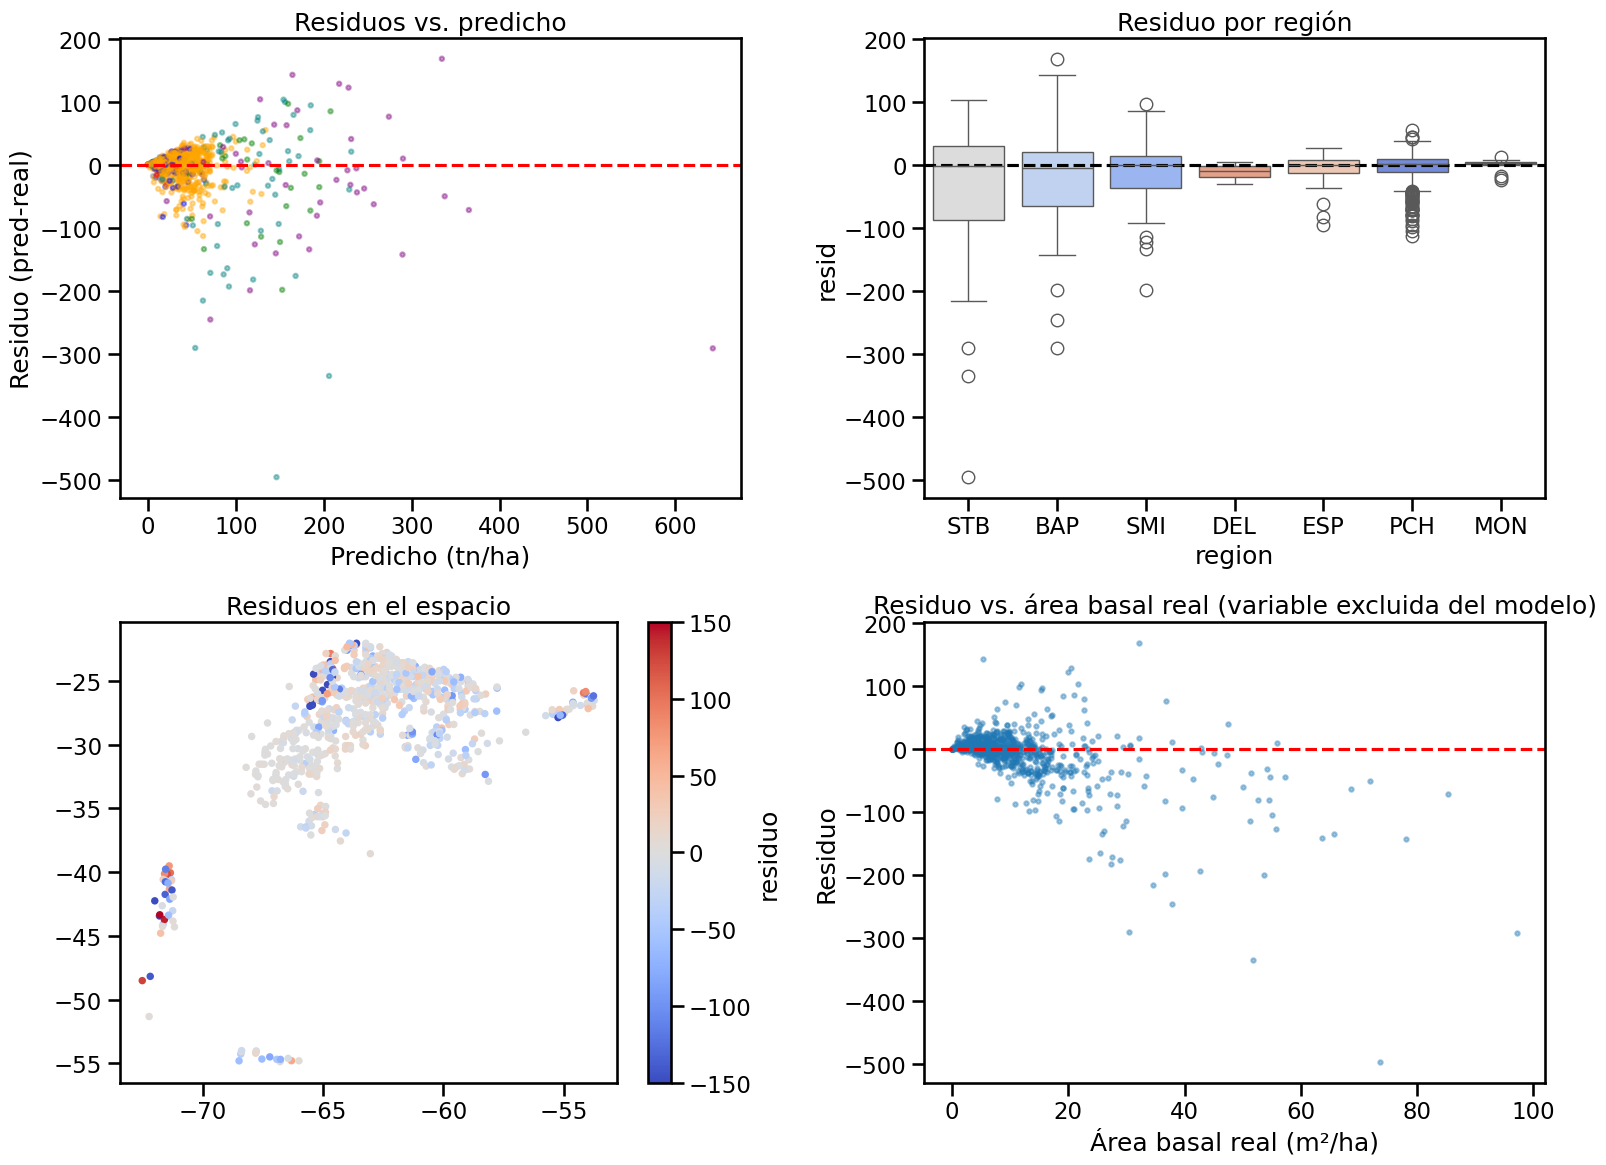

In [21]:
colores = {"BAP":"purple","STB":"teal","SMI":"green","PCH":"orange","MON":"grey","ESP":"blue","DEL":"red"}
orden = resumen.sort_values("sesgo_medio").index

fig, ax = plt.subplots(2, 2, figsize=(16, 12))
ax[0,0].scatter(p_test, resid, s=10, alpha=.4, c=[colores.get(r, "k") for r in reg_test])
ax[0,0].axhline(0, color="r", ls="--")
ax[0,0].set_xlabel("Predicho (tn/ha)"); ax[0,0].set_ylabel("Residuo (pred-real)")
ax[0,0].set_title("Residuos vs. predicho")

sns.boxplot(data=tabla, x="region", y="resid", order=orden, hue="region",
           palette="coolwarm", legend=False, ax=ax[0,1])
ax[0,1].axhline(0, color="k", ls="--"); ax[0,1].set_title("Residuo por región")

lat = d.loc[X_test.index, "LATITUD"]; lon = d.loc[X_test.index, "LONGITUD"]
sc = ax[1,0].scatter(lon, lat, c=resid, cmap="coolwarm", vmin=-150, vmax=150, s=15)
plt.colorbar(sc, ax=ax[1,0], label="residuo"); ax[1,0].set_title("Residuos en el espacio")

area_basal = d.loc[X_test.index, "AREA_BASAL_UM_HA"]
ax[1,1].scatter(area_basal, resid, s=10, alpha=.4)
ax[1,1].axhline(0, color="r", ls="--")
ax[1,1].set_xlabel("Área basal real (m²/ha)"); ax[1,1].set_ylabel("Residuo")
ax[1,1].set_title("Residuo vs. área basal real (variable excluida del modelo)")
plt.tight_layout(); plt.show()

### 3.8.3. ¿El error se explica por lo que excluimos a propósito?


In [22]:
extra = d.loc[X_test.index, ["DAP_MEDIO", "MEDIA_ALTURA_UM_EST", "AREA_BASAL_UM_HA"]]
tabla_extra = pd.DataFrame({"resid": resid}).set_index(extra.index).join(extra)
for c in extra.columns:
    print(c, "correlación con el residuo:", round(tabla_extra[c].corr(tabla_extra["resid"]), 3))

print("\nLas 10 UM con mayor error absoluto:")
tabla_full = tabla.reset_index(drop=True).join(extra.reset_index(drop=True))
tabla_full.reindex(tabla_full.resid.abs().sort_values(ascending=False).index).head(10)[
    ["region", "real", "pred", "resid", "AREA_BASAL_UM_HA"]]

DAP_MEDIO correlación con el residuo: -0.457
MEDIA_ALTURA_UM_EST correlación con el residuo: -0.414
AREA_BASAL_UM_HA correlación con el residuo: -0.546

Las 10 UM con mayor error absoluto:


,region,real,pred,resid,AREA_BASAL_UM_HA
11,STB,642.164361,146.262674,-495.901687,73.725655
504,STB,541.349708,206.047567,-335.302142,51.763369
244,BAP,934.031225,642.526821,-291.504404,97.255016
383,STB,344.728269,53.849866,-290.878403,30.408645
21,BAP,316.827019,70.993352,-245.833667,37.839651
225,STB,278.322587,62.590024,-215.732564,34.546695
445,BAP,315.558382,116.084760,-199.473623,53.597386
598,SMI,351.367349,152.743413,-198.623936,36.679955
505,STB,285.598051,92.174118,-193.423933,42.613667
282,STB,302.065217,119.715433,-182.349784,27.413180


Resultados obtenidos hasta aquí:

- **El modelo subestima sistemáticamente en los bosques de mayor biomasa.** El sesgo es negativo en todas las regiones (el modelo predice por debajo del valor real), y crece con la biomasa promedio de la región: -37.1 tn/ha en STB (Selva Tucumanao/Boliviana/Yungas, biomasa media 140) y -21.7 en BAP (Andino Patagónico, media 191), contra -4.4 en PCH (media 42) y -0.4 en MON (media 9). En términos proporcionales el sesgo relativo es más parejo (-26% en STB, -11% en BAP y -14% en SMI vs. 10% en PCH), pero en tn/ha absolutas el error se concentra ahí.
- **Las 10 UM peor predichas son casi todas de STB y BAP**, con errores de hasta -496 tn/ha (una UM real de 642 predicha en 146). Una sola UM en BAP fue sobreestimada fuerte (+179), sugiriendo que no es solo "el modelo predice bajo siempre", sino que le cuesta identificar los rodales de biomasa extrema en ambos sentidos.
- **La correlación negativa entre el residuo y el área basal real (-0.55)**: confirma la hipótesis del TP1, el error creciente en biomasa alta está relacionado con el tamaño estructural de los árboles, justamente la información que excluimos del modelo para evitar la fuga (3.2). Esto no es una falla del modelo sino una consecuencia esperada de la decisión metodológica, sin conocer el diámetro o la altura de los árboles, el modelo no puede distinguir un rodal de árboles grandes de uno de árboles chicos aunque tengan condiciones ambientales similares.
- **En el mapa de residuos**, los puntos con mayor error (más rojos/azules intensos) se concentran en el noreste (Misiones) y el noroeste (Yungas), en el sur andino-patagónico, exactamente las regiones de bosque húmedo de gran porte, mientras que el Parque Chaqueño (la mayoría de los puntos, en tonos claros) tiene errores chicos y sin patrón espacial visible.
- **Implicancia práctica:** si el objetivo fuera predecir biomasa para inventario o monitoreo, este modelo es confiable en el Parque Chaqueño pero debería complementarse con datos estructurales (o un  modelo aparte) para los bosques de biomasa alta, donde el error absoluto es mayor precisamente donde más "pesa" en términos de toneladas totales de biomasa.

### 3.8.4. Modelo en dos etapas

In [23]:
from sklearn.ensemble import GradientBoostingClassifier

hay = (y_train > 0).astype(int)
clf = Pipeline([("pre", make_pre(num_features, ord_bin_features, cat_features)),
                ("m", GradientBoostingClassifier(random_state=42))]).fit(X_train, hay)

pos = (y_train > 0).values
reg_pos = make_gb(num_features, ord_bin_features, cat_features).fit(X_train[pos], y_train[pos])

p_hat = clf.predict_proba(X_test)[:, 1]
pred_2e = np.clip(p_hat * reg_pos.predict(X_test), 0, None)
pred_gb = np.clip(modelo_final.predict(X_test), 0, None)

pd.DataFrame({
    "GB ajustado": [r2_score(y_test, pred_gb), r2_log(y_test, pred_gb), mean_absolute_error(y_test, pred_gb)],
    "Dos etapas":  [r2_score(y_test, pred_2e), r2_log(y_test, pred_2e), mean_absolute_error(y_test, pred_2e)],
}, index=["R2", "R2_log", "MAE"]).round(3)

,GB ajustado,Dos etapas
R2,0.630,0.600
R2_log,0.756,0.756
MAE,24.630,25.397


El modelo en dos etapas (clasificador de "hay árboles" × regresor sobre UM con vegetación) no mejora al GB ajustado (R² 0.600 vs 0.630; R² log idéntico, 0.756; MAE 25.4 vs 24.6). El GB entrenado sobre log1p ya resuelve bien las UM vacías (ver 3.5.4), así que la complejidad extra no se justifica y se mantiene el modelo único.

### 3.9. ¿Mejora el modelo al incorporar información espacial?

LATITUD y LONGITUD ya están en el modelo. Evaluamos su aporte de cuatro formas: (1) con vs. sin coordenadas, (2) dejando una región completa fuera del entrenamiento, (3) validación cruzada por bloques geográficos (cuenca forestal) y (4) autocorrelación espacial de los residuos.

In [24]:
from sklearn.model_selection import RepeatedStratifiedKFold
num_sin = [c for c in num_features if c not in ("LATITUD", "LONGITUD")]
rskf = list(RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42).split(X_train, strat_train))

res, folds = [], {}
for nombre, num in [("Sin coordenadas", num_sin), ("Con coordenadas", num_features)]:
    m = make_gb(num, ord_bin_features, cat_features)
    cv = cross_validate(m, X_train, y_train, cv=rskf, scoring=scoring)
    folds[nombre] = cv["test_R2"]
    m.fit(X_train, y_train)
    p = np.clip(m.predict(X_test), 0, None)
    res.append({"modelo": nombre, "R2_cv": cv["test_R2"].mean(), "sd_cv": cv["test_R2"].std(),
                "R2_log_cv": cv["test_R2_log"].mean(), "MAE_cv": -cv["test_MAE"].mean(),
                "R2_test": r2_score(y_test, p), "MAE_test": mean_absolute_error(y_test, p)})
display(pd.DataFrame(res).set_index("modelo").round(3))

dif = folds["Con coordenadas"] - folds["Sin coordenadas"]
print(f"Diferencia de R² por fold (con - sin): media {dif.mean():.3f}, sd {dif.std():.3f}, "
      f"folds a favor de coordenadas: {(dif > 0).mean()*100:.0f}%")

,R2_cv,sd_cv,R2_log_cv,MAE_cv,R2_test,MAE_test
modelo,,,,,,
Sin coordenadas,0.522,0.060,0.717,26.245,0.629,25.392
Con coordenadas,0.547,0.075,0.738,25.364,0.630,24.630


Diferencia de R² por fold (con - sin): media 0.025, sd 0.040, folds a favor de coordenadas: 73%


Se quita una región fuera: `REGION_OFC`de las categóricas, porque la región no vista no puede ser codificada.

In [25]:
cat_sin_reg = [c for c in cat_features if c != "REGION_OFC"]
filas = []
for r in d["REGION_OFC"].value_counts().index:
    te = (d["REGION_OFC"] == r).values
    Xa, Xb = d.loc[~te, predictores], d.loc[te, predictores]
    ya, yb = d.loc[~te, target], d.loc[te, target]
    base = mean_absolute_error(yb, np.full(len(yb), ya.median()))
    for nombre, num in [("sin coords", num_sin), ("con coords", num_features)]:
        m = make_gb(num, ord_bin_features, cat_sin_reg).fit(Xa, ya)
        p = np.clip(m.predict(Xb), 0, None)
        filas.append({"region_excluida": r, "n": te.sum(), "modelo": nombre,
                      "real_medio": yb.mean(), "sesgo": (p - yb).mean(),
                      "MAE": mean_absolute_error(yb, p), "MAE_mediana_train": base,
                      "R2": r2_score(yb, p)})
loro = pd.DataFrame(filas).round(2)
loro.pivot(index="region_excluida", columns="modelo", values=["sesgo", "MAE", "R2"])

sesgo                   MAE                    R2           
modelo          con coords sin coords con coords sin coords con coords sin coords
region_excluida                                                                  
BAP                -192.26    -158.08     192.27     161.37      -1.12      -0.69
DEL                  -7.57      -7.17      17.01      17.67       0.21       0.18
ESP                  -6.78      -5.03      18.94      19.08       0.08       0.12
MON                   1.97       5.76       7.24      10.25       0.08      -0.65
PCH                  38.45      28.96      47.46      42.92      -2.29      -2.08
SMI                 -77.79     -63.03      80.59      71.93      -0.49      -0.30
STB                 -73.65     -66.92      76.12      77.31      -0.47      -0.47

### 3.9.3. CV espacial por bloques geográficos

In [26]:
# Bloques espaciales: 8 agrupamientos geográficos de las UM de entrenamiento
coord = d.loc[X_train.index, ["LATITUD", "LONGITUD"]]
coord_z = (coord - coord.mean()) / coord.std()
bloques = KMeans(8, random_state=42, n_init=10).fit_predict(coord_z)
print("UM por bloque:", np.bincount(bloques))

filas = []
for nombre, num in [("Sin coords", num_sin), ("Con coords", num_features)]:
    m = make_gb(num, ord_bin_features, cat_features)
    for esq, splits in [("Aleatoria", list(KFold(5, shuffle=True, random_state=42).split(X_train))),
                        ("Por bloque espacial", list(GroupKFold(5).split(X_train, y_train, groups=bloques)))]:
        r = cross_validate(m, X_train, y_train, cv=splits, scoring=scoring)
        filas.append({"modelo": nombre, "validacion": esq, "R2": r["test_R2"].mean(),
                      "sd": r["test_R2"].std(), "R2_log": r["test_R2_log"].mean(),
                      "MAE": -r["test_MAE"].mean()})
pd.DataFrame(filas).round(3)

UM por bloque: [424 663 145 309 774  48 133 616]


,modelo,validacion,R2,sd,R2_log,MAE
0,Sin coords,Aleatoria,0.520,0.056,0.721,26.201
1,Sin coords,Por bloque espacial,0.172,0.267,0.412,36.331
2,Con coords,Aleatoria,0.551,0.053,0.747,25.118
3,Con coords,Por bloque espacial,0.141,0.296,0.192,37.442


Resultados obtenidos hasta aquí:

- **Validación aleatoria:** agregar coordenadas mejora levemente la CV (R² 0.547 vs 0.522 en la CV repetida; 0.551 vs 0.520 con KFold simple; a favor en el 73% de los folds, diferencia media 0.025 con desvío 0.040), pero en el test la diferencia desaparece (0.630 vs 0.629). El efecto es pequeño y del orden del ruido entre folds.
- **Región excluida:** las coordenadas no ayudan a extrapolar. Empeoran el error en BAP (MAE 192 vs 161), SMI (81 vs 72) y PCH (47 vs 43), y solo mejoran en MON (7.2 vs 10.2). En ESP, DEL y STB no hay diferencia relevante. En ninguna región el modelo logra buen desempeño cuando no la vio durante el entrenamiento (sesgo de hasta -192 tn/ha en BAP).
- **CV por bloques geográficos:** al exigir predecir en zonas no vistas, el R² cae de ≈0.52–0.55 (validación aleatoria) a ≈0.14–0.17, con una dispersión muy alta entre bloques (desvío de 0.27–0.30). Aquí las coordenadas no solo no ayudan, el modelo con coordenadas rinde peor (R² 0.141 vs 0.172; R² log 0.192 vs 0.412; MAE 37.4 vs 36.3). Con coordenadas el modelo parece aprender patrones locales de la zona de entrenamiento que no se trasladan a zonas nuevas.
- **Conclusión:** la información espacial aporta, como mucho, una mejora marginal dentro de zonas ya muestreadas y no mejora (incluso perjudica) la generalización a zonas nuevas. Buena parte de su señal ya está en `REGION_OFC`, `TIPO_PAISAJE` y `ALTITUD`.
- **Limitación:** una primera versión agrupaba por `CUENCA_FORESTAL`, pero el 88% de las UM está en `sin_cuenca` y los folds quedaban muy desbalanceados, por lo que se reemplazó por bloques construidos con las coordenadas (8 bloques de entre 48 y 774 UM). Esa heterogeneidad de tamaños aumenta la variabilidad de la estimación.

## 3.10. Anexo: ¿qué pasa si usamos las variables alométricas?

En 3.2 decidimos excluir del modelo principal las variables que son insumo directo de la fórmula con
la que se calculó la biomasa (`DAP_MEDIO`, `DAP_MAX`, `MEDIA_ALTURA_UM_EST`, etc.), para que el modelo
respondiera una pregunta ecológica genuina. Como anexo, mostramos qué pasa si las incluimos: sirve para
cuantificar cuán fuerte es esa relación (algo que en el TP1 se vio como correlación, y acá lo vemos
como capacidad predictiva).

In [27]:
alometricas = ["DAP_MEDIO", "DAP_MAX", "DAP_DESVIO", "DAP_CV",
               "MEDIA_ALTURA_UM_EST", "ALTURA_MAX", "ESBELTEZ_MEDIA", "PROP_IND_GRANDES"]

predictores_full = predictores + alometricas
X_train_full = d.loc[X_train.index, predictores_full]
X_test_full  = d.loc[X_test.index,  predictores_full]

# Ahora las alométricas entran como numéricas (imputadas con mediana: solo faltan en las UM sin árboles)
m_full = make_gb(num_features + alometricas, ord_bin_features, cat_features)
m_full.fit(X_train_full, y_train)

TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('pre',
                                                      ColumnTransformer(transformers=[('num',
                                                                                       Pipeline(steps=[('imputer',
                                                                                                        SimpleImputer(strategy='median')),
                                                                                                       ('scaler',
                                                                                                        RobustScaler())]),
                                                                                       ['LATITUD',
                                                                                        'LONGITUD',
                                                                                        'ALTITUD',
                                                                                        'RIQUEZA_ESPECIES',
                                                                                        'SHANNON',
                                                                                        'DOMINANCIA',
                                                                                        'N_FORMAS_VIDA',
                                                                                        'DENSIDAD_MADERA_PONDERA...
                                                                                        'EROSION_PRESENCIA',
                                                                                        'TIENE_TOCONES']),
                                                                                      ('cat',
                                                                                       Pipeline(steps=[('imputer',
                                                                                                        SimpleImputer(strategy='most_frequent')),
                                                                                                       ('onehot',
                                                                                                        OneHotEncoder(handle_unknown='ignore'))]),
                                                                                       ['REGION_OFC',
                                                                                        'EXPOSICION',
                                                                                        'TIPO_PAISAJE',
                                                                                        'CUENCA_FORESTAL'])])),
                                                     ('m',
                                                      GradientBoostingRegressor(learning_rate=0.05,
                                                                                max_depth=5,
                                                                                min_samples_leaf=5,
                                                                                n_estimators=300,
                                                                                random_state=42,
                                                                                subsample=0.6))]))

In [28]:
# Relación de una sola variable

ab_train = d.loc[X_train.index, "AREA_BASAL_UM_HA"].values.reshape(-1, 1)
ab_test = d.loc[X_test.index, "AREA_BASAL_UM_HA"].values.reshape(-1, 1)
lr = LinearRegression().fit(np.log1p(ab_train), np.log1p(y_train))
p_ab = np.expm1(lr.predict(np.log1p(ab_test)))
print("Solo área basal (regresión log-log) -> R² test:", round(r2_score(y_test, p_ab), 3),
      " R² log test:", round(r2_log(y_test, p_ab), 3))

Solo área basal (regresión log-log) -> R² test: 0.702  R² log test: 0.896


In [29]:
# Importancia de las variables en ese modelo
perm_full = permutation_importance(m_full, X_test_full, y_test, n_repeats=15, random_state=42, scoring="r2")
pd.DataFrame({"variable": X_test_full.columns, "importancia": perm_full.importances_mean}) \
  .sort_values("importancia", ascending=False).head(10)

,variable,importancia
25,MEDIA_ALTURA_UM_EST,0.433924
22,DAP_MAX,0.402556
8,CANTIDAD_IND_VIVOS_HA,0.392294
21,DAP_MEDIO,0.319521
26,ALTURA_MAX,0.267082
7,DENSIDAD_MADERA_PONDERADA,0.067348
28,PROP_IND_GRANDES,0.022650
23,DAP_DESVIO,0.009868
24,DAP_CV,0.005038
12,OTBN_ORD,0.003765


In [30]:
p_tr = np.clip(m_full.predict(X_train_full), 0, None)
p_te = np.clip(m_full.predict(X_test_full), 0, None)
print("R² train:", round(r2_score(y_train, p_tr), 3))
print("R² test:", round(r2_score(y_test, p_te), 3))
print("R² log test:", round(r2_log(y_test, p_te), 3))
print("MAE test:", round(mean_absolute_error(y_test, p_te), 2))

R² train: 0.985
R² test: 0.871
R² log test: 0.97
MAE test: 9.98


Resultados obtenidos hasta aquí:

- **La capacidad predictiva salta de ~0.55-0.63 a 0.87 de R²**, y el error se reduce a menos de la mitad (MAE de 26 a 10 tn/ha), simplemente por agregar variables que describen el tamaño de los árboles. Esto confirma cuantitativamente, con capacidad predictiva y no solo correlación, la relación alométrica ya identificada en el TP1.
- **Con una sola variable (área basal) y una regresión log-log simple** ya se supera el desempeño de todo el modelo ecológico con 21 variables. Esto ilustra por qué decidimos separarlas en 3.2: no es que las variables ambientales "no sirvan", es que compiten en un plano completamente distinto de información con las estructurales.
- **Las variables que más aportan acá son exactamente las de tamaño** (altura media, DAP máximo y medio), y no las de composición o ambiente que dominaban el modelo principal — es coherente: la biomasa se calcula matemáticamente a partir de esos valores.
- **Conclusión metodológica:** si el objetivo fuera únicamente maximizar la precisión de la predicción de biomasa (por ejemplo, para completar UM con mediciones incompletas de DAP/altura), este sería el modelo a usar. Pero si el objetivo es entender qué condiciones ambientales y de manejo se asocian a más o menos biomasa, la pregunta de la consigna, el modelo de 3.5-3.9, aunque tenga menor R², es el que responde algo genuinamente nuevo: el modelo de esta sección en gran parte "mide lo que ya se sabía" (biomasa = función de DAP y altura), mientras que el otro identifica qué condiciones producen árboles grandes en primer lugar.

## 3.11. Complemento no supervisado: ¿existen grupos ecológicos de UM?

### 3.11.1. Agrupamiento de UM

Como complemento al modelo predictivo, exploramos si las UM se agrupan naturalmente en función de sus
características estructurales, de composición y ambientales, sin usar la región administrativa como
insumo (para ver si el agrupamiento la "redescubre" o encuentra algo distinto).

Usamos 10 variables que resumen estructura (biomasa, área basal, densidad de individuos), composición
(riqueza, Shannon, densidad de madera), tamaño de árboles (DAP medio, altura media), ambiente (altitud)
y presión antrópica. Las variables de cola larga (biomasa, área basal, densidad de individuos) se
transforman con `log1p` antes de estandarizar, igual criterio que en el modelo supervisado.

In [31]:

vars_cluster = ["BIOMASA_TN_HA", "AREA_BASAL_UM_HA", "CANTIDAD_IND_VIVOS_HA", "RIQUEZA_ESPECIES",
               "SHANNON", "DAP_MEDIO", "MEDIA_ALTURA_UM_EST", "DENSIDAD_MADERA_PONDERADA",
               "ALTITUD", "PRESION_ANTROPICA"]

dc = d.dropna(subset=vars_cluster).reset_index(drop=True)
print(f"UM utilizadas: {len(dc)} de {len(d)} ({len(dc)/len(d)*100:.1f}%)")

Xc = dc[vars_cluster].copy()
for c in ["BIOMASA_TN_HA", "AREA_BASAL_UM_HA", "CANTIDAD_IND_VIVOS_HA"]:
    Xc[c] = np.log1p(Xc[c])
Xc_scaled = (Xc - Xc.mean()) / Xc.std()

UM utilizadas: 3809 de 3890 (97.9%)


Se excluyen 81 UM: 75 son las UM sin individuos del TP2 y 6 más con DENSIDAD_MADERA_PONDERADA nula

### 3.11.2. Elección de k

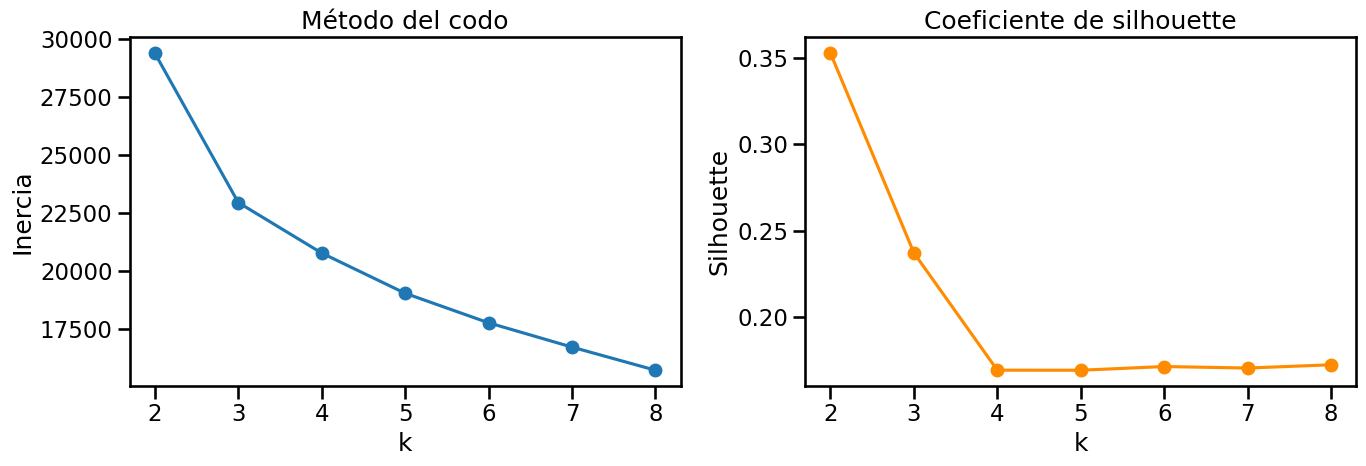

In [32]:
inercias, siluetas = [], []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xc_scaled)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(Xc_scaled, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(range(2, 9), inercias, "o-")
ax[0].set_xlabel("k"); ax[0].set_ylabel("Inercia"); ax[0].set_title("Método del codo")
ax[1].plot(range(2, 9), siluetas, "o-", color="darkorange")
ax[1].set_xlabel("k"); ax[1].set_ylabel("Silhouette"); ax[1].set_title("Coeficiente de silhouette")
plt.tight_layout(); plt.show()

Resultados obtenidos hasta aquí:

El silhouette es más alto en k=2 (0.353), y cae a 0.24 en k=3 y se estabiliza entre 0.17-0.18 de k=4 en adelante, es decir, estadísticamente la partición "más limpia" es en 2 grupos, pero eso solo distinguiría biomasa alta vs. baja, sin matices. El codo de la inercia se atenúa a partir
de k=4. Priorizamos interpretabilidad ecológica sobre el silhouette puro: se eligió **k=4** por interpretabilidad, sabiendo que el silhouette favorece k=2.

### 3.11.3. Perfil de los clusters (k=4)

In [33]:
km4 = KMeans(n_clusters=4, random_state=42, n_init=10).fit(Xc_scaled)
dc["cluster"] = km4.labels_

perfil = dc.groupby("cluster")[vars_cluster].mean().round(1)
perfil["n"] = dc["cluster"].value_counts().sort_index()
display(perfil)

display(pd.crosstab(dc["cluster"], dc["REGION_OFC"], normalize="index").round(2))

,BIOMASA_TN_HA,AREA_BASAL_UM_HA,CANTIDAD_IND_VIVOS_HA,RIQUEZA_ESPECIES,SHANNON,DAP_MEDIO,MEDIA_ALTURA_UM_EST,DENSIDAD_MADERA_PONDERADA,ALTITUD,PRESION_ANTROPICA,n
cluster,,,,,,,,,,,
0,175.7,30.4,385.5,3.5,0.8,35.5,13.4,0.6,962.6,0.3,435
1,42.6,9.0,493.9,5.6,1.3,16.7,6.3,0.9,223.0,0.4,1553
2,87.7,16.2,687.3,10.7,2.0,19.1,8.1,0.8,235.2,0.4,947
3,11.9,3.5,199.0,3.0,0.8,16.4,5.3,0.8,401.2,0.5,874


REGION_OFC,BAP,DEL,ESP,MON,PCH,SMI,STB
cluster,,,,,,,
0,0.46,0.01,0.01,0.00,0.04,0.06,0.41
1,0.00,0.01,0.09,0.01,0.87,0.01,0.01
2,0.00,0.00,0.02,0.00,0.79,0.12,0.06
3,0.03,0.00,0.11,0.09,0.72,0.01,0.04


In [34]:
def eta2(col):
    g = Xc_scaled[col].groupby(dc["cluster"])
    ssb = sum(len(v) * (v.mean() - Xc_scaled[col].mean())**2 for _, v in g)
    sst = ((Xc_scaled[col] - Xc_scaled[col].mean())**2).sum()
    return ssb / sst

pd.Series({c: eta2(c) for c in vars_cluster}).sort_values(ascending=False).round(2).rename("eta² (varianza explicada por cluster)")

,eta² (varianza explicada por cluster)
RIQUEZA_ESPECIES,0.66
BIOMASA_TN_HA,0.64
AREA_BASAL_UM_HA,0.63
SHANNON,0.49
MEDIA_ALTURA_UM_EST,0.49
DAP_MEDIO,0.47
CANTIDAD_IND_VIVOS_HA,0.41
ALTITUD,0.37
DENSIDAD_MADERA_PONDERADA,0.32
PRESION_ANTROPICA,0.07


### 3.11.4. Robustez del clustering

ARI vs. partición original (bootstrap): 0.77 ± 0.17
ARI KMeans vs. GMM: 0.29
ARI sin biomasa ni área basal: 0.34


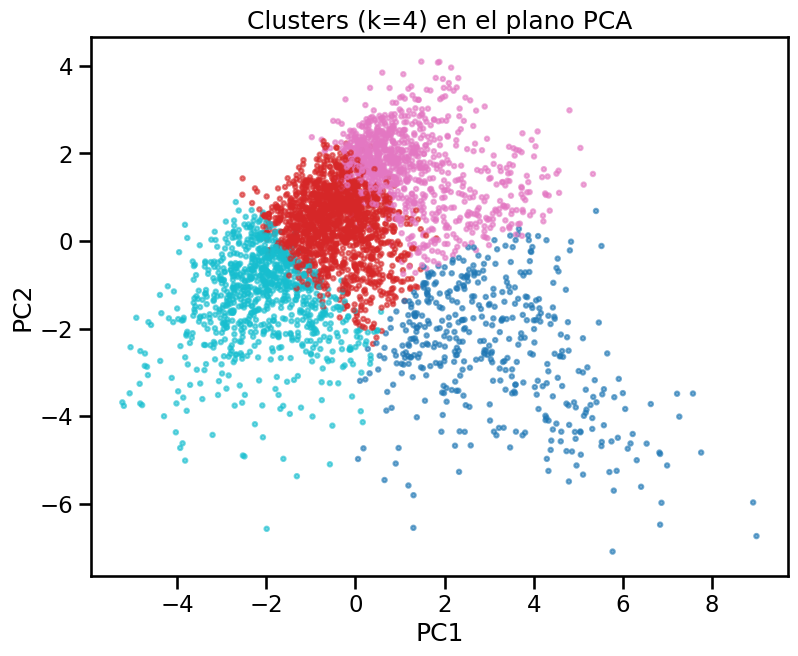

In [35]:
from sklearn.metrics import adjusted_rand_score
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

# (a) Estabilidad por bootstrap
rng = np.random.RandomState(0)
aris = []
for b in range(30):
    idx = rng.choice(len(Xc_scaled), len(Xc_scaled), replace=True)
    kmb = KMeans(4, n_init=10, random_state=b).fit(Xc_scaled.iloc[idx])
    aris.append(adjusted_rand_score(km4.labels_, kmb.predict(Xc_scaled)))
print(f"ARI vs. partición original (bootstrap): {np.mean(aris):.2f} ± {np.std(aris):.2f}")

# (b) Otro algoritmo
gmm = GaussianMixture(4, random_state=42, n_init=5).fit(Xc_scaled)
print("ARI KMeans vs. GMM:", round(adjusted_rand_score(km4.labels_, gmm.predict(Xc_scaled)), 2))

# (c) Sin las variables del target/estructura, ¿persisten los grupos?
v2 = [v for v in vars_cluster if v not in ("BIOMASA_TN_HA", "AREA_BASAL_UM_HA")]
X2 = Xc_scaled[v2]
km_b = KMeans(4, random_state=42, n_init=10).fit(X2)
print("ARI sin biomasa ni área basal:", round(adjusted_rand_score(km4.labels_, km_b.labels_), 2))

# (d) Proyección PCA
pc = PCA(2).fit_transform(Xc_scaled)
plt.figure(figsize=(9, 7))
plt.scatter(pc[:, 0], pc[:, 1], c=dc["cluster"], cmap="tab10", s=10, alpha=.6)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("Clusters (k=4) en el plano PCA"); plt.show()

**Robustez: los grupos son útiles para describir, pero no son fronteras nítidas.**
- El silhouette para k=4 es bajo (≈0.17): las UM forman un continuo más que grupos bien separados. Elegimos k=4 por interpretabilidad ecológica, no por evidencia estadística de que existan exactamente cuatro grupos.
- Con remuestreo bootstrap, la partición es moderadamente estable (ARI 0.77 ± 0.17), pero varía bastante entre remuestreos.
- Con otro algoritmo (GMM) la coincidencia es baja (ARI 0.29), y sin biomasa ni área basal como insumo también es baja (ARI 0.34). Es decir, la partición depende en buena medida de las variables de biomasa y de estructura.
- Por eso interpretamos los clusters como una descripción del gradiente estructural, no como tipologías definitivas.
- Según eta², los grupos se separan sobre todo por riqueza de especies, biomasa y área basal. La presión antrópica casi no los distingue (η²=0.07).

**Resultados**

El agrupamiento, sin usar la región como insumo, distingue cuatro perfiles con sentido  claro:

- **Cluster 0 — "Bosque de gran porte y baja diversidad" (435 UM, 11%):** biomasa y área basal más altas, árboles de mayor diámetro y altura, mayor altitud, baja riqueza de especies y baja presión antrópica. Corresponde casi enteramente a BAP y STB, es decir, agrupa juntas a dos regiones administrativas distintas (Andino Patagónico y Selva Tucumano Boliviana) porque comparten un mismo patrón estructural: pocos árboles, pero grandes, en zonas de altura y poco intervenidas.
- **Cluster 3 — "Chaco de baja biomasa" (874 UM, 22%):** biomasa mínima (11.9 tn/ha), menor densidad de individuos, baja diversidad y la mayor presión antrópica del dataset (0.5). Casi todo Chaco, pero identifica dentro de esa región un subconjunto de condición estructural más pobre.
- **Cluster 1 — "Chaco típico" (1.553 UM, 41%, el más numeroso):** biomasa y estructura intermedias, diversidad moderada. Es el "Chaco promedio".
- **Cluster 2 — "Chaco y  Selva Misionera, diverso y denso" (947 UM, 25%):** la mayor riqueza de especies (10.7) y diversidad de Shannon (2.0) de los cuatro grupos, junto con la mayor densidad de individuos por hectárea (687), y biomasa notablemente más alta que el Chaco típico (87.7 vs. 42.6 tn/ha) con árboles algo mayores (DAP medio 19.1 vs. 16.7 cm).

**Conclusión:** el agrupamiento no supervisado reproduce en parte las regiones administrativas (el Parque Chaqueño se reparte entre tres clusters), pero aporta algo que la región sola no muestra: **dentro del Chaco hay una gradiente estructural clara**, desde rodales degradados de baja diversidad y alta presión antrópica (cluster 3) hasta rodales densos y diversos con más biomasa (cluster 2), pasando por la condición "típica" (cluster 1). Esto es coherente con lo que el modelo supervisado no podía capturar bien dentro de una misma región (sección 3.8): hay heterogeneidad estructural real puertas adentro de cada región que la variable `REGION_OFC` por sí sola no expresa, y que en cambio el
clustering sugiere separar usando directamente las variables estructurales y de composición.

## 3.12. Conclusiones finales



### ¿Qué variables explican mejor la biomasa?

Con un enfoque estrictamente ecológico (sin usar variables que sean insumo directo del cálculo de
biomasa), el modelo elegido (Gradient Boosting ajustado) explica entre 55% y 63% de la varianza de la
biomasa por hectárea (R² test), y hasta 70-76% en escala logarítmica. La variable más importante por
lejos es la **región** (importancia de permutación de 0.47, muy por encima de la siguiente), seguida
por la **densidad de madera de las especies presentes, la posición geográfica dentro de la región, el
tipo de paisaje y la densidad de individuos por hectárea**. La **presión antrópica**, pese a
correlacionar con la biomasa de forma simple, aporta poco una vez que el modelo ya conoce la región:
su efecto parece estar mayormente absorbido por diferencias estructurales entre regiones, más que
actuar como un factor local fuerte.

Si se permite usar variables de tamaño de los árboles (DAP, altura — el anexo de la sección 3.10), el
R² sube a 0.87 y el error se reduce a menos de la mitad. Esto no contradice lo anterior: simplemente
confirma, con capacidad predictiva y no solo con correlación, la relación alométrica ya identificada en
el TP1. Son dos preguntas distintas: una explica la biomasa a partir de su propia fórmula de cálculo
(circular, aunque útil para completar datos faltantes), la otra explica qué condiciones ambientales y
de manejo producen rodales con más o menos biomasa (la pregunta de fondo del proyecto).

### ¿Cómo evaluamos el desempeño del modelo? ¿Existe sobreajuste?

Usamos R², RMSE y MAE, en escala original y logarítmica, con un split estratificado por región y
validación cruzada de 5 folds para no depender de una sola partición. Sí existe sobreajuste, y su
magnitud depende del modelo: el Random Forest por defecto muestra una brecha train-test de 0.33 en R²,
mientras que el Gradient Boosting, incluso ajustado, mantiene una brecha más moderada (0.22) con mejor
desempeño en datos no vistos. La regularización (aumentar `min_samples_leaf`) reduce la brecha pero a
costa de peor desempeño en test — no hay una solución sin costo. La validación cruzada mostró además
que la estimación de un único split (R² ≈ 0.55) era algo optimista: el rango real esperado es más
amplio (0.44 a 0.59 según el fold). El análisis de residuos reveló que el error no es homogéneo: es
bajo en el Parque Chaqueño (la mayoría del dataset) y sube fuertemente en las regiones de biomasa alta
y baja representación (BAP, STB, SMI), correlacionado con el área basal real de esas UM — el modelo
tiene más dificultad exactamente donde tiene menos ejemplos para aprender.

### ¿Mejora el modelo al incorporar información espacial?

La respuesta es matizada: la información espacial aporta poco y no ayuda a generalizar. En la comparación con validación cruzada aleatoria, latitud y longitud mejoran levemente el desempeño (R² 0.547 vs 0.522), pero en el test la diferencia es nula (0.630 vs 0.629). Al dejar una región completa fuera del entrenamiento, el desempeño se derrumba (sesgos de hasta -192 tn/ha en BAP) y las coordenadas tienden a empeorarlo en vez de corregirlo. Con validación por bloques geográficos el R² baja de ≈0.52–0.55 a ≈0.14–0.17, y el modelo con coordenadas rinde incluso peor que el que no las usa (R² 0.141 vs 0.172; R² log 0.192 vs 0.412). Es consistente con lo observado en 3.7, donde LONGITUD y LATITUD figuran entre las variables más importantes dentro de las regiones ya muestreadas: capturan variación geográfica fina, pero no permiten extrapolar a territorio nuevo. En la práctica, el modelo es útil para predecir nuevas UM dentro de regiones conocidas, no para extrapolar a zonas no relevadas.

### Aporte del análisis no supervisado

El agrupamiento (k=4), hecho sin usar la región como insumo, reprodujo en parte la geografía
administrativa pero también reveló algo que el modelo supervisado no podía ver: dentro del **mismo**
Parque Chaqueño hay una gradiente estructural real, desde rodales degradados de baja diversidad y alta
presión antrópica hasta rodales densos y diversos de mayor biomasa. Esta heterogeneidad intra-regional
es probablemente parte de lo que el modelo supervisado no logra capturar (sección 3.8: el error no es
cero ni siquiera dentro de Chaco), y sugiere que un modelo futuro podría beneficiarse de usar el
cluster estructural, y no solo la región administrativa, como predictor.

### Síntesis

En conjunto, el trabajo muestra que la biomasa del bosque nativo argentino está fuertemente
estructurada por **tipo de bosque/región** y, dentro de cada región, por variables de **composición de
especies y densidad del rodal**, más que por variables puramente climáticas o topográficas aisladas. La
presión antrópica y la erosión sí se asocian a menor biomasa a nivel simple, pero su efecto queda en
gran medida diluido detrás de las diferencias estructurales entre regiones. Y quizás la lección
metodológica más relevante: un buen desempeño de validación cruzada dentro de las regiones muestreadas
no garantiza que el modelo sirva para predecir en zonas no representadas en el inventario — una
distinción crítica para cualquier uso futuro de este tipo de modelos en política forestal o monitoreo
de nuevas áreas.